In [2]:
using JSON
using Plots
using Distributions

In [3]:
# -----------------------------
# SALVATAGGIO (più flessibile)
# -----------------------------
function save_CCE_results(filename, x_pos, CCE_mean, CCE_std; params=nothing)

    results = Dict(
        "x_pos" => collect(x_pos),
        "CCE_mean" => CCE_mean,
        "CCE_std" => CCE_std
    )

    # aggiunge params solo se forniti
    if params !== nothing
        results["params"] = params
    end

    open(filename, "w") do f
        JSON.print(f, results, 4)
    end

    println("Salvato file: ", filename)
end


# -----------------------------
# LETTURA (robusta)
# -----------------------------
function load_CCE_results(filename)

    data = JSON.parsefile(filename)

    # --- caso 1: formato semplice (il tuo attuale)
    if haskey(data, "x_pos")
        x   = Float64.(data["x_pos"])
        cce = Float64.(data["CCE_mean"])
        err = Float64.(data["CCE_std"])
        params = haskey(data, "params") ? data["params"] : Dict()

    # --- caso 2: formato annidato
    elseif haskey(data, "data")
        d = data["data"]
        x   = Float64.(d["x_pos"])
        cce = Float64.(d["CCE_mean"])
        err = Float64.(d["CCE_std"])
        params = haskey(data, "params") ? data["params"] : Dict()

    else
        error("Formato JSON non riconosciuto")
    end

    return x, cce, err, params
end

load_CCE_results (generic function with 1 method)

# CONFRONTO GIOVANETTI vs MIO CODICE CON 1 Litio - size

In [4]:
# questa è la curva CCE fatta con il codice di gioavnetti, dx = 20 um, 1000 charges, 25 rep
xR, cceR, errR, params_loaded = load_CCE_results("Radford/Radford_CCE.json");
# questa è la curva CCE fatta con il codice mio, dx = 20 um, 1000 charges, 25 rep
xMM, cceMM, errMM, params_loaded = load_CCE_results("my model/My-uncomplete-model.json");

SystemError: SystemError: opening file "my model/My-uncomplete-model.json": No such file or directory

In [5]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1

plt = plot(xR.*10, cceR, lw=3, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label="Giovanetti model",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), frame=:box, size=(600, 500)
)
plot!(xMM.*10, cceMM, lw=3, color=:deepskyblue, label = "My model")


plot!(
    xR.*10, cceR,
    yerr=errR,
    seriestype=:scatter,
    color=:black,
    marker=:circle,
    ms=1.5,
    label=false,
)


plot!(
    xMM.*10, cceMM,
    yerr=errMM,
    seriestype=:scatter,
    color=:black,
    marker=:circle,
    ms=1.5,
    label=false
)

savefig(plt, "plot/CCE_comparison.png")
display(plt)

UndefVarError: UndefVarError: `xMM` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# CONFRONTO MIO MODELLO CON 1 LITIO vs DIEMENSIONE LITIO RANDOMICA

In [43]:
# questa è la curva CCE fatta con il codice di gioavnetti, dx = 20 um, 500 charges, 25 rep
x_1Li, cce_1Li, err_1Li, params_loaded = load_CCE_results("my model/json-CCE-file/My-uncomplete-model.json");
# questa è la curva CCE fatta con il codice mio, dx = 20 um, 1000 charges, 25 rep
x_RLi, cce_RLi, err_RLi, params_loaded = load_CCE_results("my model/json-CCE-file/random-Li.json");


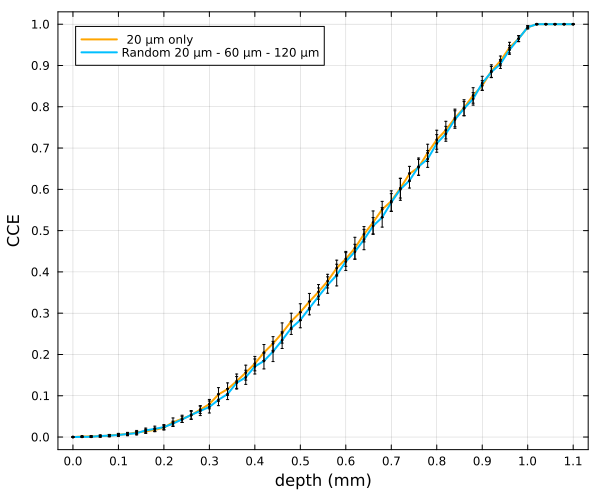

In [44]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1

plt = plot(x_1Li.*10, cce_1Li, lw=2, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label=" 20 μm only",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), frame=:box, size=(600, 500)
)
plot!(x_RLi.*10, cce_RLi, lw=2, color=:deepskyblue, label = "Random 20 μm - 60 μm - 120 μm")


plot!(
    x_1Li.*10, cce_1Li,
    yerr=err_1Li,
    seriestype=:scatter,
    color=:black,
    marker=:circle,
    ms=1.5,
    label=false,
)


plot!(
    x_RLi.*10, cce_RLi,
    yerr=err_RLi,
    seriestype=:scatter,
    color=:black,
    marker=:circle,
    ms=1.5,
    label=false
)

savefig(plt, "plot/CCE_comparison_different_Li_sizes.png")
display(plt)

# Comparison my model + reald diffusivity

In [15]:
# questa è la curva CCE fatta con il codice di gioavnetti, dx = 20 um, 500 charges, 25 rep
xMM, cceMM, errMM, params_loaded = load_CCE_results("my model/json-CCE-file/My-uncomplete-model.json");
# questa è la curva CCE fatta con il mio codice + la diffusività che  dipende dalla posizione, dx = 20 um, 1000 charges, 25 rep
x_D, cce_D, err_D, params_loaded = load_CCE_results("my model/json-CCE-file/Diffusivity_CCE.json");


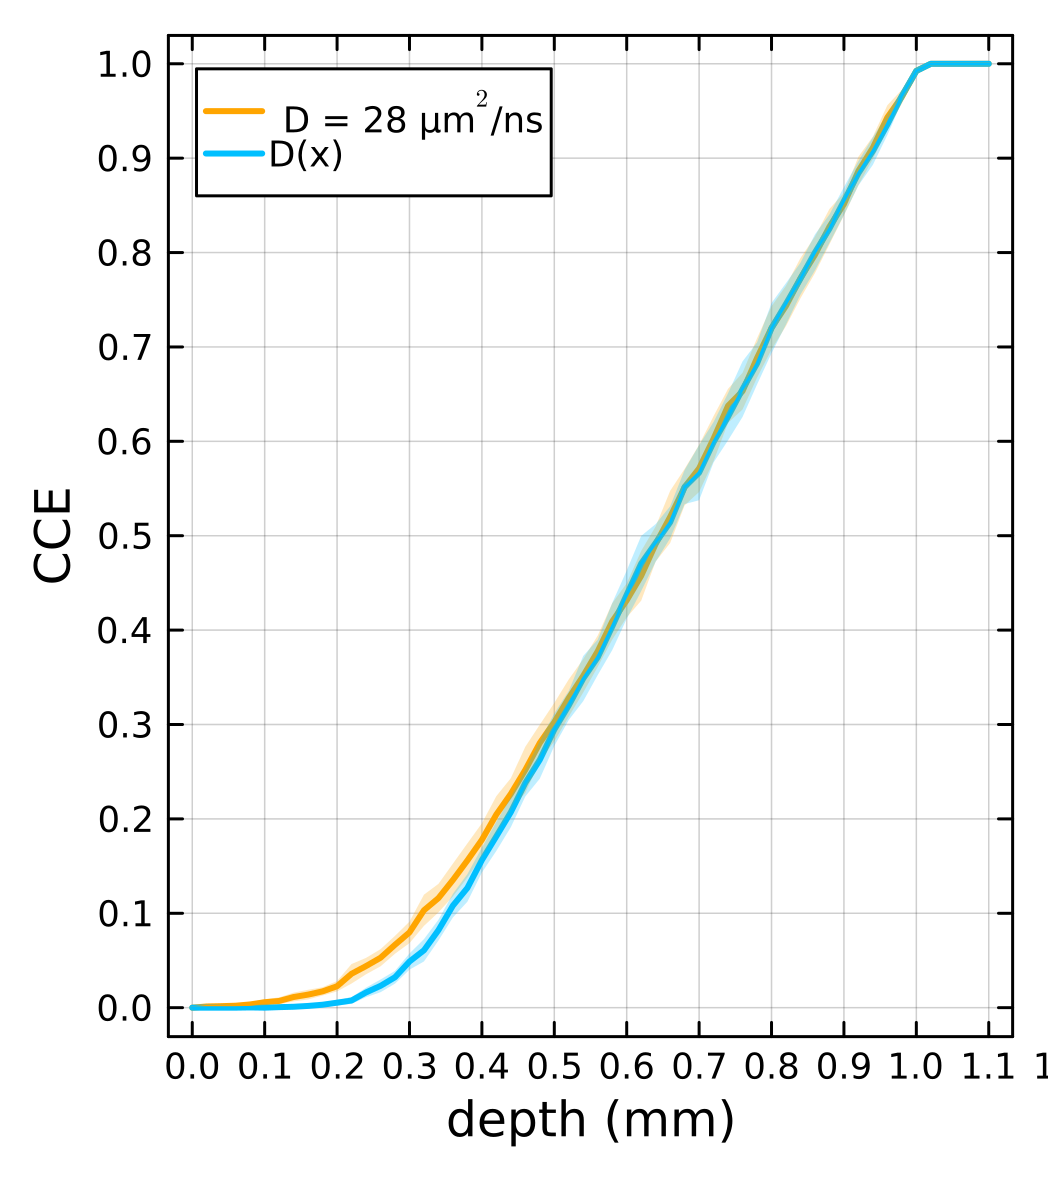

In [22]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1



plt = plot(xMM.*10, cceMM, lw=2, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label=" D = 28 μm\$^2\$/ns",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), 
    frame=:box, size=(350, 400), dpi = 300
)
plot!(x_D.*10, cce_D, lw=2, color=:deepskyblue, label = "D(x)")


plot!(
    xMM.*10, 
    cceMM,
        ribbon=errMM,
        fillalpha=0.25,
        color=:orange,
        label=false
)


plot!(
    x_D.*10, 
    cce_D,
        ribbon=err_D,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)


savefig(plt, "plot/CCE_comparison_mymodel_D_real.png")
display(plt)

# Comparison my model + Giova unif + Giov erf

In [50]:
# questa è la curva CCE fatta con il codice di gioavnetti, dx = 20 um, 500 charges, 25 rep
xMM, cceMM, errMM, params_loaded = load_CCE_results("my model/json-CCE-file/My-uncomplete-model.json");
# questa è la curva CCE fatta con Giovanetti unif(0.5%) , 500 charges, 50 rep
x_05, cce_05, err_05, params_loaded = load_CCE_results("Radford/Radford_CCE.json");
# questa è la curva CCE fatta con Giovanetti + 1.5*erf , 500 charges, 25 rep
x_erf, cce_erf, err_erf, params_loaded = load_CCE_results("my model/json-CCE-file/erf-1.5%.json");


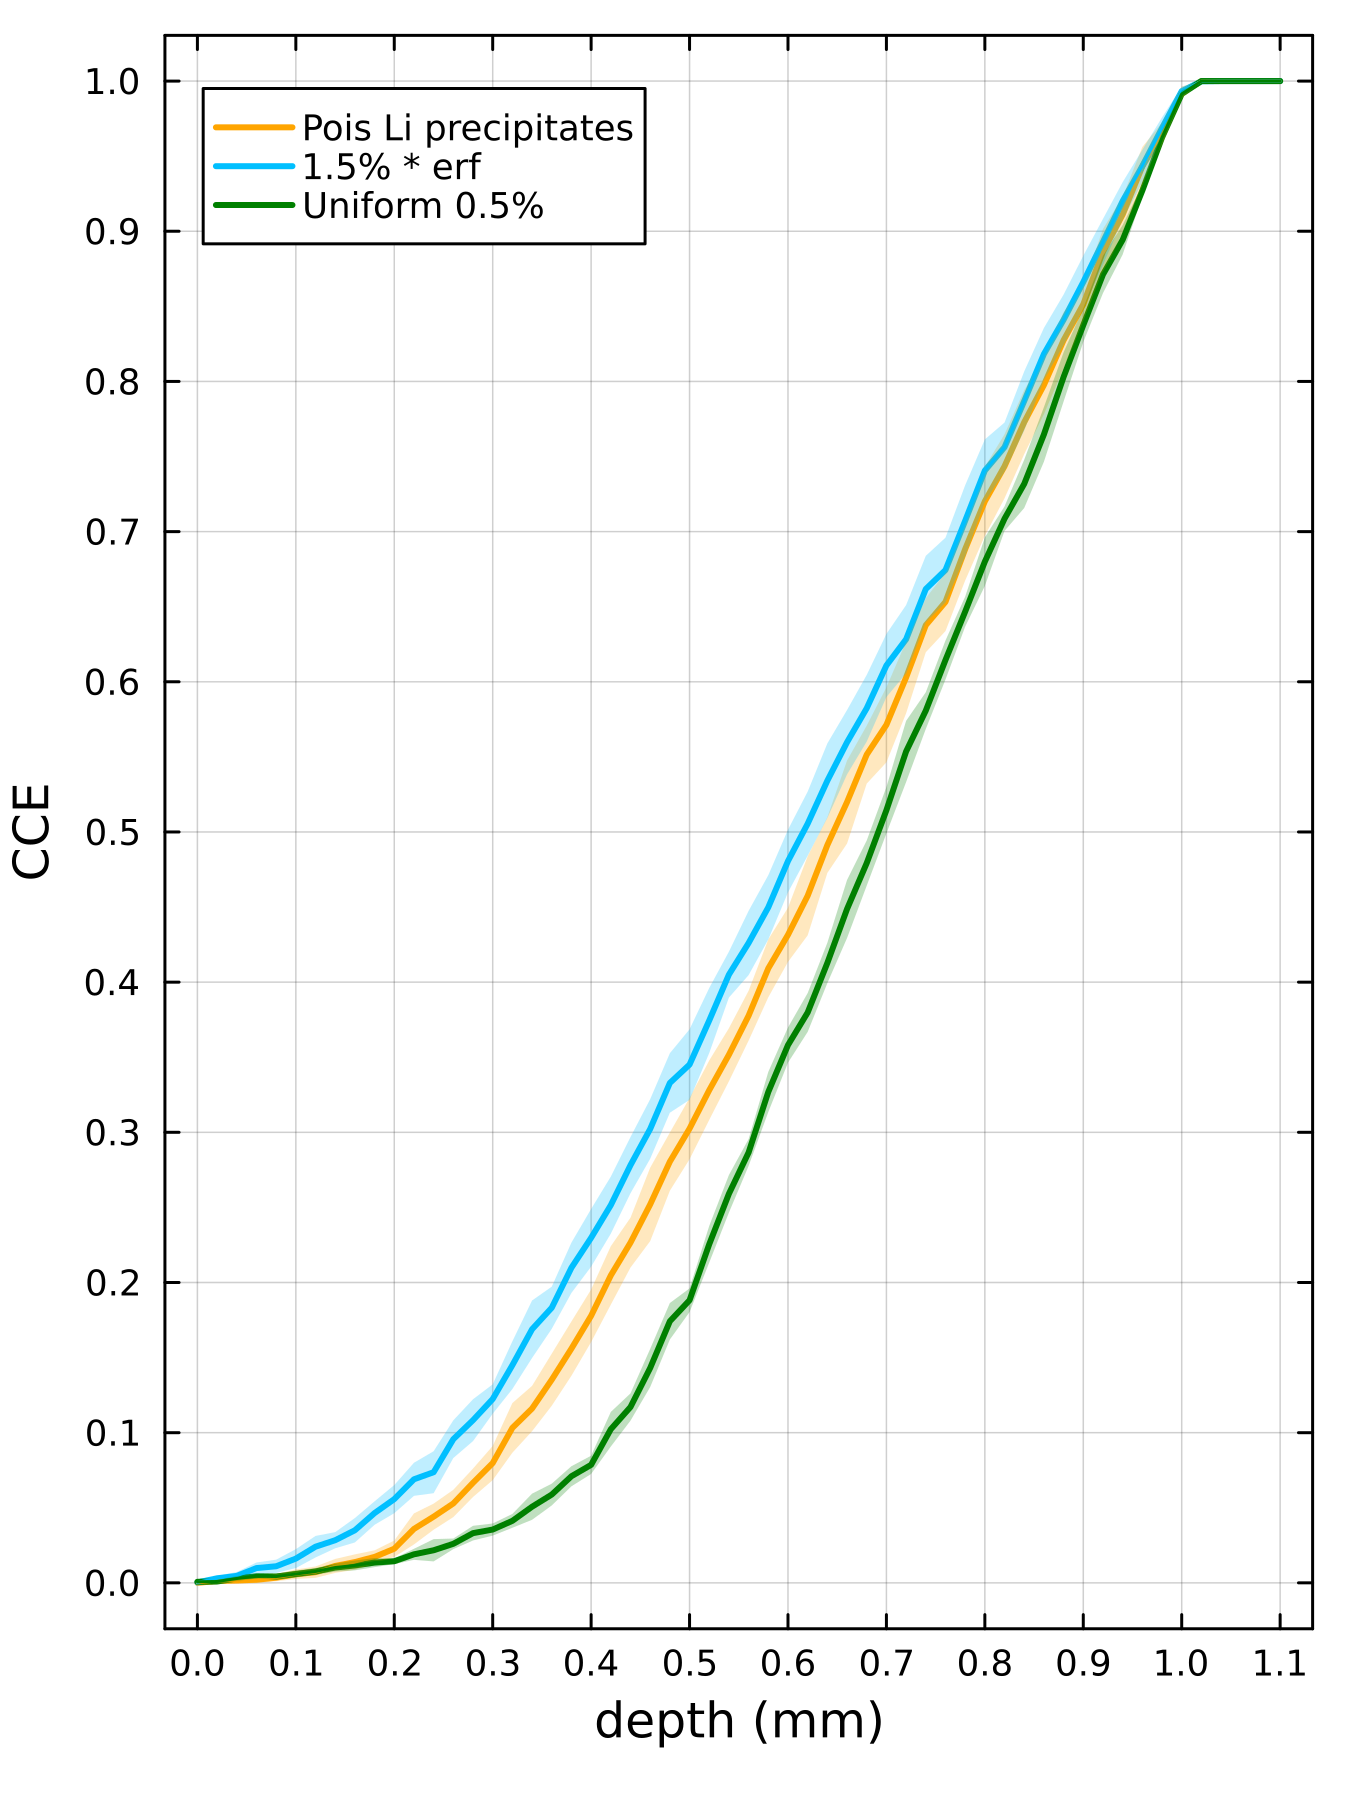

In [54]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1



plt = plot(xMM.*10, cceMM, lw=2, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label="Pois Li precipitates",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), frame=:box, size=(450, 600), dpi = 300
)
plot!(x_erf.*10, cce_erf, lw=2, color=:deepskyblue, label = "1.5% * erf")
plot!(x_05.*10, cce_05, lw=2, color=:green, label = "Uniform 0.5%")


plot!(
    xMM.*10, 
    cceMM,
        ribbon=errMM,
        fillalpha=0.25,
        color=:orange,
        label=false
)


plot!(
    x_erf.*10, 
    cce_erf,
        ribbon=err_erf,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)
plot!(
    x_05.*10, 
    cce_05,
        ribbon=err_05,
        fillalpha=0.25,
        color=:green,
        label=false
)



savefig(plt, "plot/CCE_comparison_MM_Giov05_giova1.5%erf.png")
display(plt)

# My model + Claudia tau(x)

In [59]:
# questa è la curva CCE fatta con il codice di gioavnetti, dx = 20 um, 500 charges, 25 rep
xMM, cceMM, errMM, params_loaded = load_CCE_results("my model/json-CCE-file/My-uncomplete-model.json");
# questa è la curva CCE fatta con codice Claudia-stile ma avendo il tempo che dipende dalla posizione , charge = 500, rep = 25
filename = "my model/json-CCE-file/tau_model_results_1,6e-11.json"
data = JSON.parsefile(filename)
x_τ = Float64.(data["x_pos"])
alpha = "1.6e-11"  
cce_τ = Float64.(data["alphas"][alpha]["CCE_mean"])
err_τ  = Float64.(data["alphas"][alpha]["CCE_std"]);

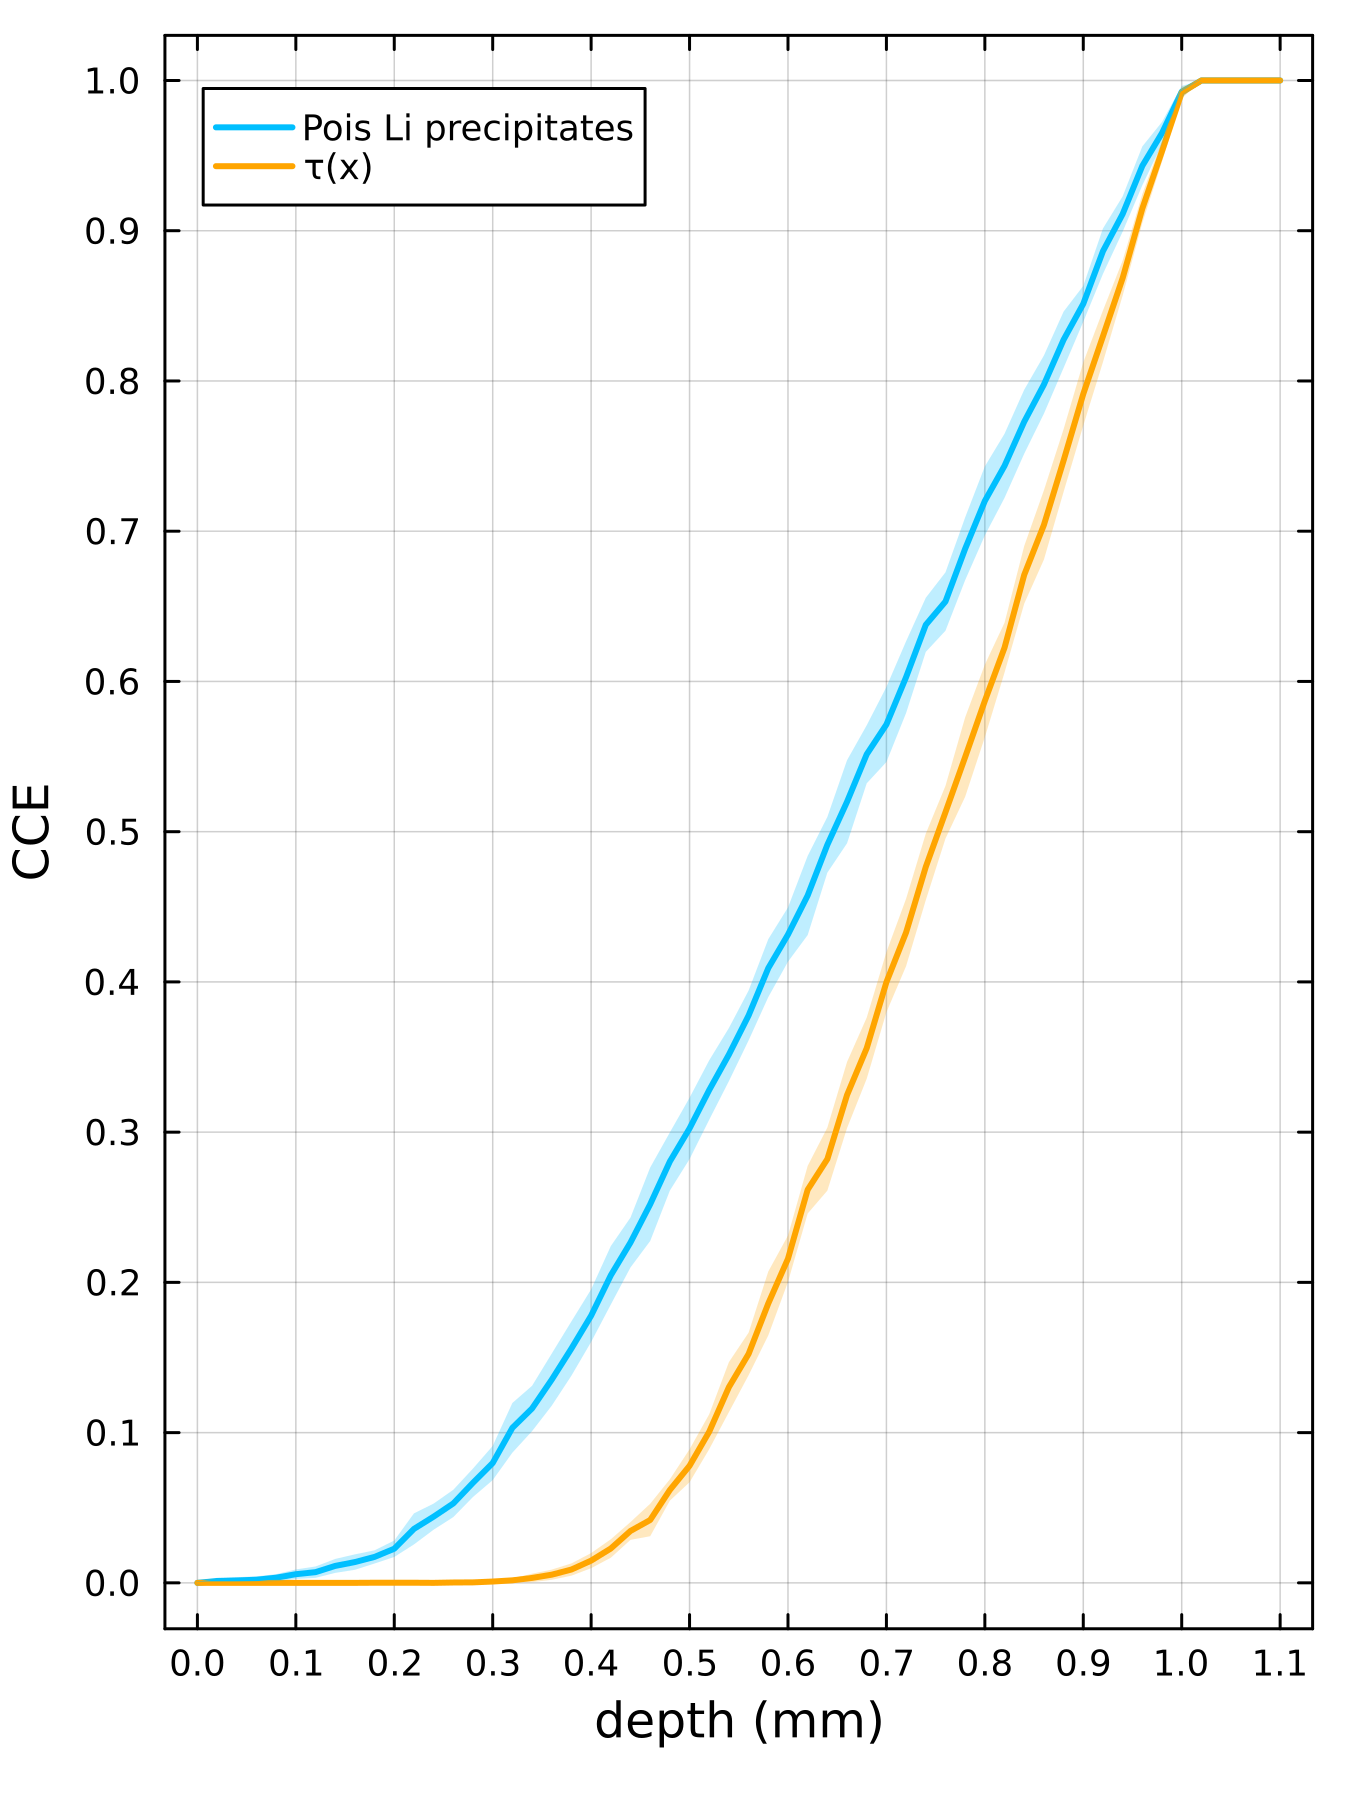

In [61]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1



plt = plot(xMM.*10, cceMM, lw=2, color=:deepskyblue,
    xlabel="depth (mm)", ylabel="CCE", label="Pois Li precipitates",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), frame=:box, size=(450, 600), dpi = 300
)
plot!(x_erf.*10, cce_τ, lw=2, color=:orange, label = "τ(x)")

plot!(
    xMM.*10, 
    cceMM,
        ribbon=errMM,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)
plot!(
    x_τ.*10, 
    cce_τ,
        ribbon=err_τ,
        fillalpha=0.25,
        color=:orange,
        label=false
)



savefig(plt, "plot/CCE_comparison_MM_tau(x).png")
display(plt)

# COmparison My model + my model with constant tau

In [63]:
# questa è la curva CCE fatta con il codice di gioavnetti, dx = 20 um, 500 charges, 25 rep
xMM, cceMM, errMM, params_loaded = load_CCE_results("my model/json-CCE-file/My-uncomplete-model.json");
# questa è la curva CCE fatta con il mio metodo ma con una probabilità costante di trapping , 500 charges, 50 rep
x_800ns, cce_800ns, err_800ns, params_loaded = load_CCE_results("my model/json-CCE-file/Point-Li-and-const-tau-800ns.json");


bha secondo me non ha molto senso... oerchè dovrei avere una probabilità che dipende dal time-stamp? dovrebbe essere una prpbabilità che dipenda al più dalla dimensione del precipitato... ma così non è tenere ijnn considerazione due volte lo stesso fattore geometrico?

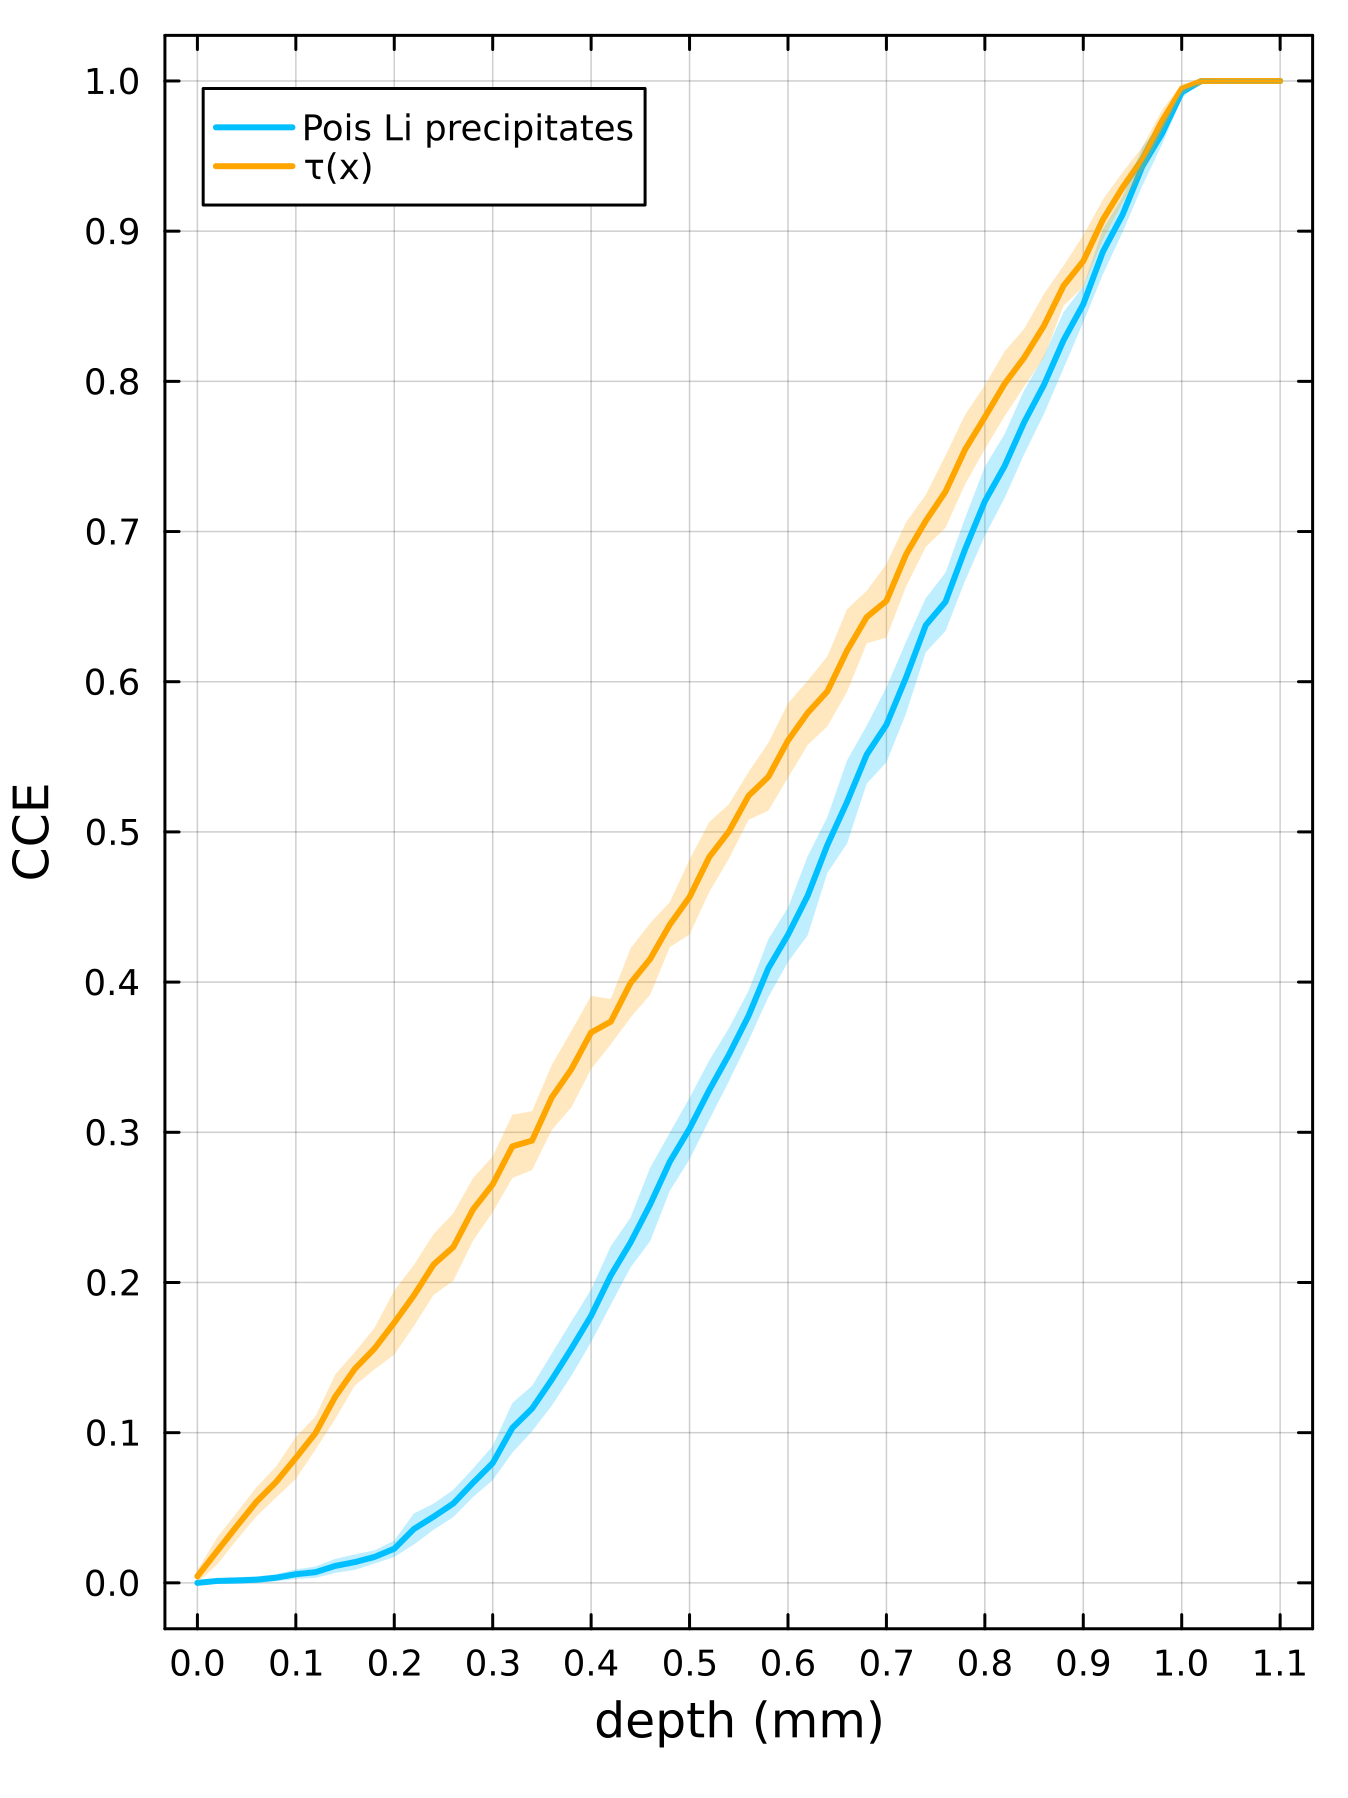

In [ ]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1



plt = plot(xMM.*10, cceMM, lw=2, color=:deepskyblue,
    xlabel="depth (mm)", ylabel="CCE", label="Pois Li precipitates",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), frame=:box, size=(450, 600), dpi = 300
)
plot!(x_800ns.*10, cce_800ns, lw=2, color=:orange, label = "τ = 800 ns")

plot!(
    xMM.*10, 
    cceMM,
        ribbon=errMM,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)
plot!(
    x_800ns.*10, 
    cce_800ns,
        ribbon=err_800ns,
        fillalpha=0.25,
        color=:orange,
        label=false
)



savefig(plt, "plot/CCE_comparison_MM_MM+constant tau.png")
display(plt)

# My model + My model RDR

In [4]:
# questa è la curva CCE fatta con il codice di gioavnetti, dx = 20 um, 500 charges, 25 rep
xMM, cceMM, errMM, params_loaded = load_CCE_results("my model/json-CCE-file/My-uncomplete-model.json");
# questa è la curva CCE fatta con il mio metodo ma con RDR , 500 charges, 25 rep
x_RDR, cce_RDR, err_RDR, params_loaded = load_CCE_results("my model/json-CCE-file/My-model+RDR.json");


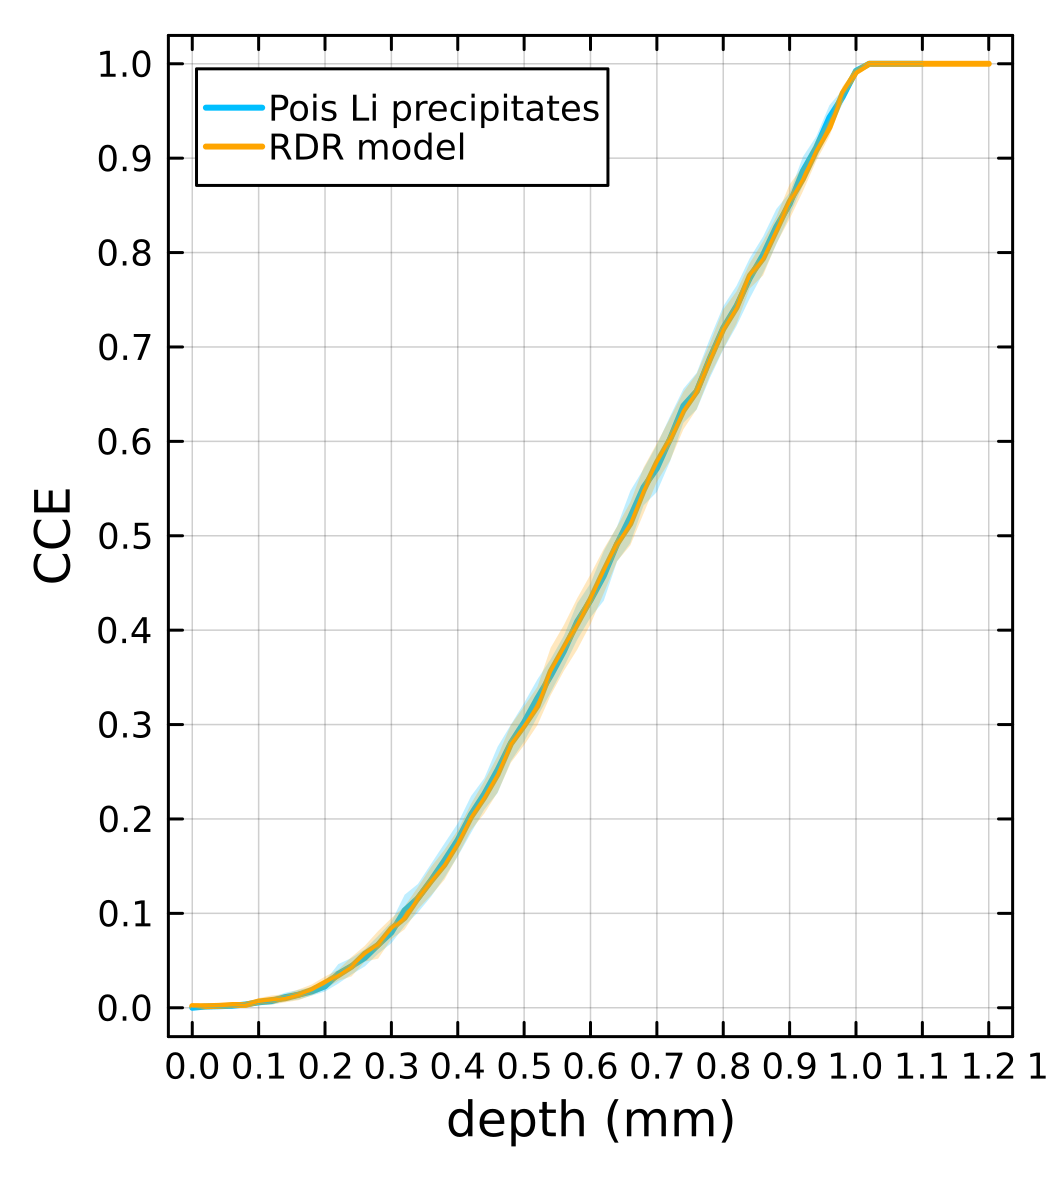

In [8]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1


plt = plot(xMM.*10, cceMM, lw=2, color=:deepskyblue,
    xlabel="depth (mm)", ylabel="CCE", label="Pois Li precipitates",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), 
    frame=:box, size=(350, 400), dpi = 300
)
plot!(x_RDR.*10, cce_RDR, lw=2, color=:orange, label = "RDR model")

plot!(
    xMM.*10, 
    cceMM,
        ribbon=errMM,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)
plot!(
    x_RDR.*10, 
    cce_RDR,
        ribbon=err_RDR,
        fillalpha=0.25,
        color=:orange,
        label=false
)



savefig(plt, "plot/CCE_comparison_MM_MM+RDR.png")
display(plt)

# confornto tau(x) + tau(x e RDR)

In [9]:
# questa è la curva CCE fatta con codice Claudia-stile ma avendo il tempo che dipende dalla posizione + RDR , charge = 500, rep = 25
filename = "my model/json-CCE-file/tau(x).json"
x_RDR, cce_RDR, err_RDR, params_loaded = load_CCE_results(filename);

# questa è la curva CCE fatta con codice Claudia-stile ma avendo il tempo che dipende dalla posizione , charge = 500, rep = 25
filename = "my model/json-CCE-file/tau_model_results_1,6e-11.json"
data = JSON.parsefile(filename)
x_τ = Float64.(data["x_pos"])
alpha = "1.6e-11"  
cce_τ = Float64.(data["alphas"][alpha]["CCE_mean"])
err_τ  = Float64.(data["alphas"][alpha]["CCE_std"]);

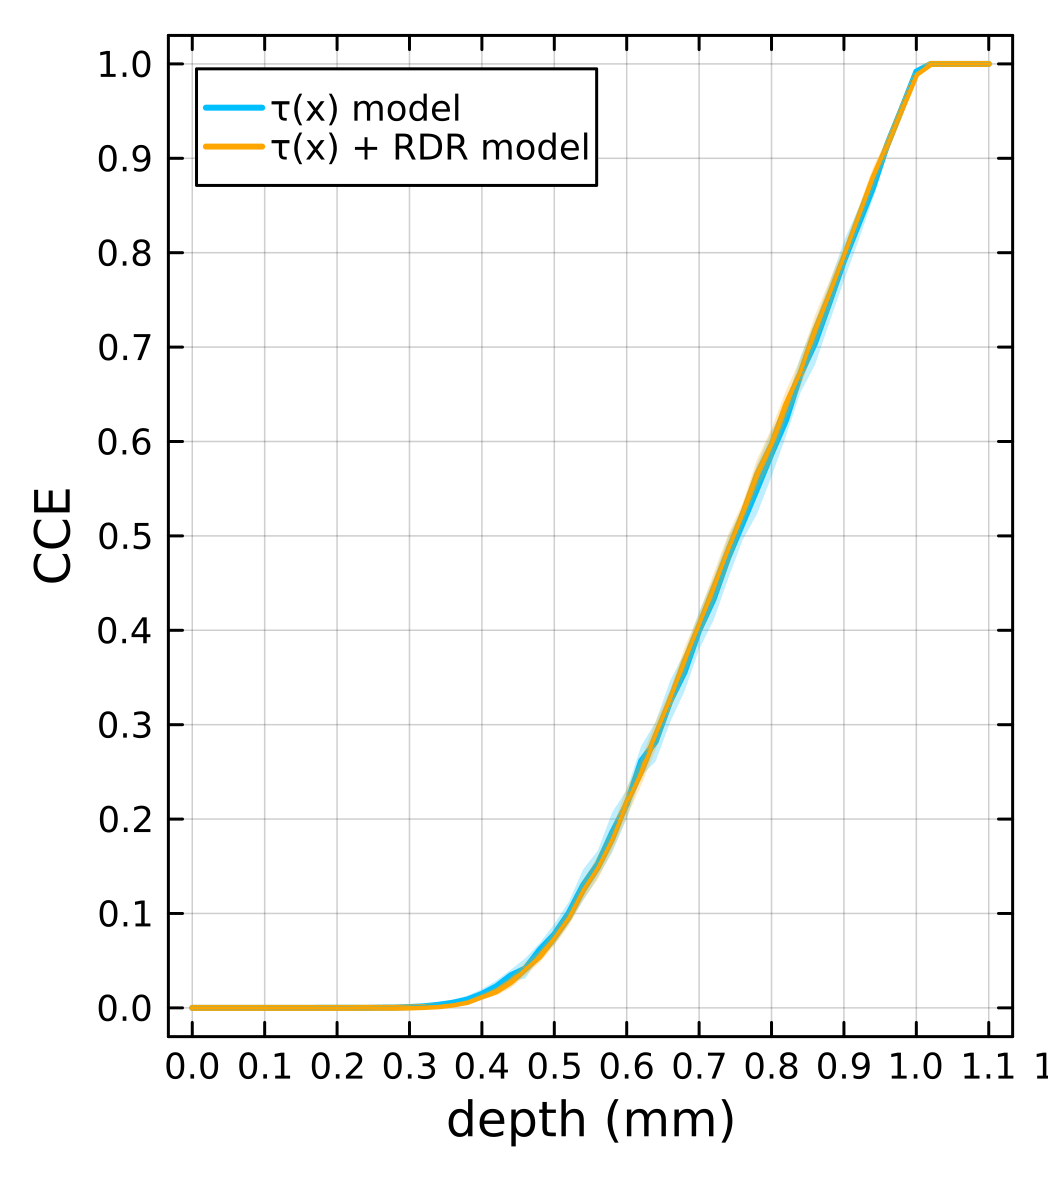

In [10]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1


plt = plot(x_τ.*10, cce_τ, lw=2, color=:deepskyblue,
    xlabel="depth (mm)", ylabel="CCE", label="τ(x) model",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), 
    frame=:box, size=(350, 400), dpi = 300
)
plot!(x_RDR.*10, cce_RDR, lw=2, color=:orange, label = "τ(x) + RDR model")

plot!(
    x_τ.*10, 
    cce_τ,
        ribbon=err_τ,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)
plot!(
    x_RDR.*10, 
    cce_RDR,
        ribbon=err_RDR,
        fillalpha=0.25,
        color=:orange,
        label=false
)



savefig(plt, "plot/CCE_comparison_τ(x)_τ(x)+RDR.png")
display(plt)

# codice dopop aver torvato l'errore del x6 invece di x2

In [3]:
# questa è la curva CCE fatta con il codice di gioavnetti con x6, dx = 20 um, 500 charges, 25 rep
x3d, cce3d, err3d, params_loaded = load_CCE_results("Radford/Radford_CCE.json");
# questa è la curva CCE fatta con il codice di gioavnetti con x2, dx = 20 um, 500 charges, 25 rep
x1d, cce1d, err1d, params_loaded = load_CCE_results("Radford/Radford_CCE_1D.json");



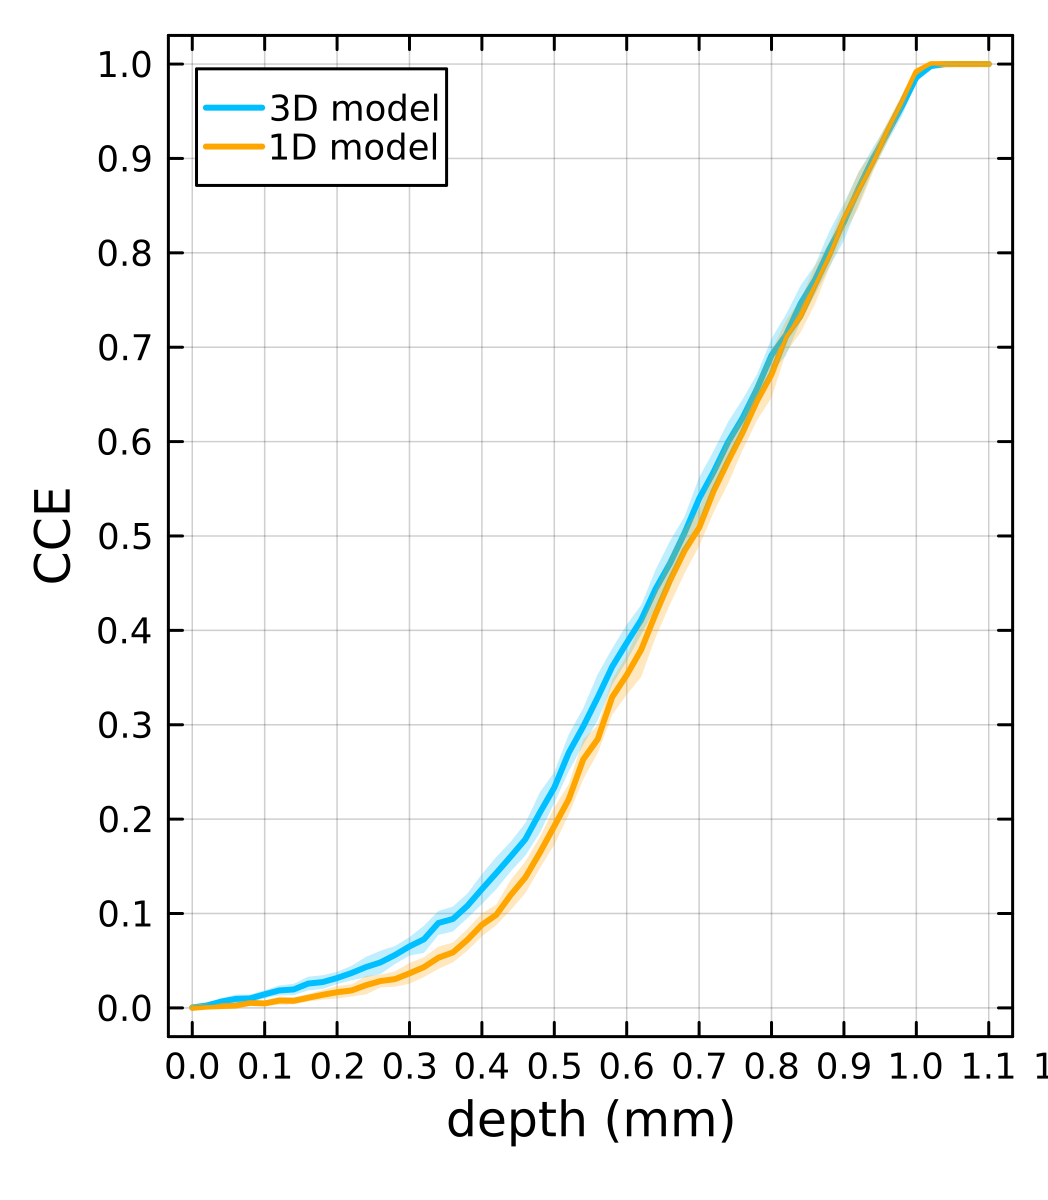

In [4]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1


plt = plot(x3d.*10, cce3d, lw=2, color=:deepskyblue,
    xlabel="depth (mm)", ylabel="CCE", label="3D model",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), 
    frame=:box, size=(350, 400), dpi = 300
)
plot!(x1d.*10, cce1d, lw=2, color=:orange, label = "1D model")

plot!(
    x3d.*10, 
    cce3d,
        ribbon=err3d,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)
plot!(
    x1d.*10, 
    cce1d,
        ribbon=err1d,
        fillalpha=0.25,
        color=:orange,
        label=false
)



savefig(plt, "plot/CCE_comparison_3D_1D.png")
display(plt)

# confronto Giovanetti +  my uncomplete model

In [6]:
# questa è la curva CCE fatta con il codice di gioavnetti con x6, dx = 20 um, 500 charges, 25 rep
xg, cceg, errg, params_loaded = load_CCE_results("Radford/Radford_CCE.json");
# questa è la curva CCE fatta con il mio codice, dx = 20 um, 500 charges, 25 rep
xmm, ccemm, errmm, params_loaded = load_CCE_results("my model/My-uncomplete-model-3D.json");



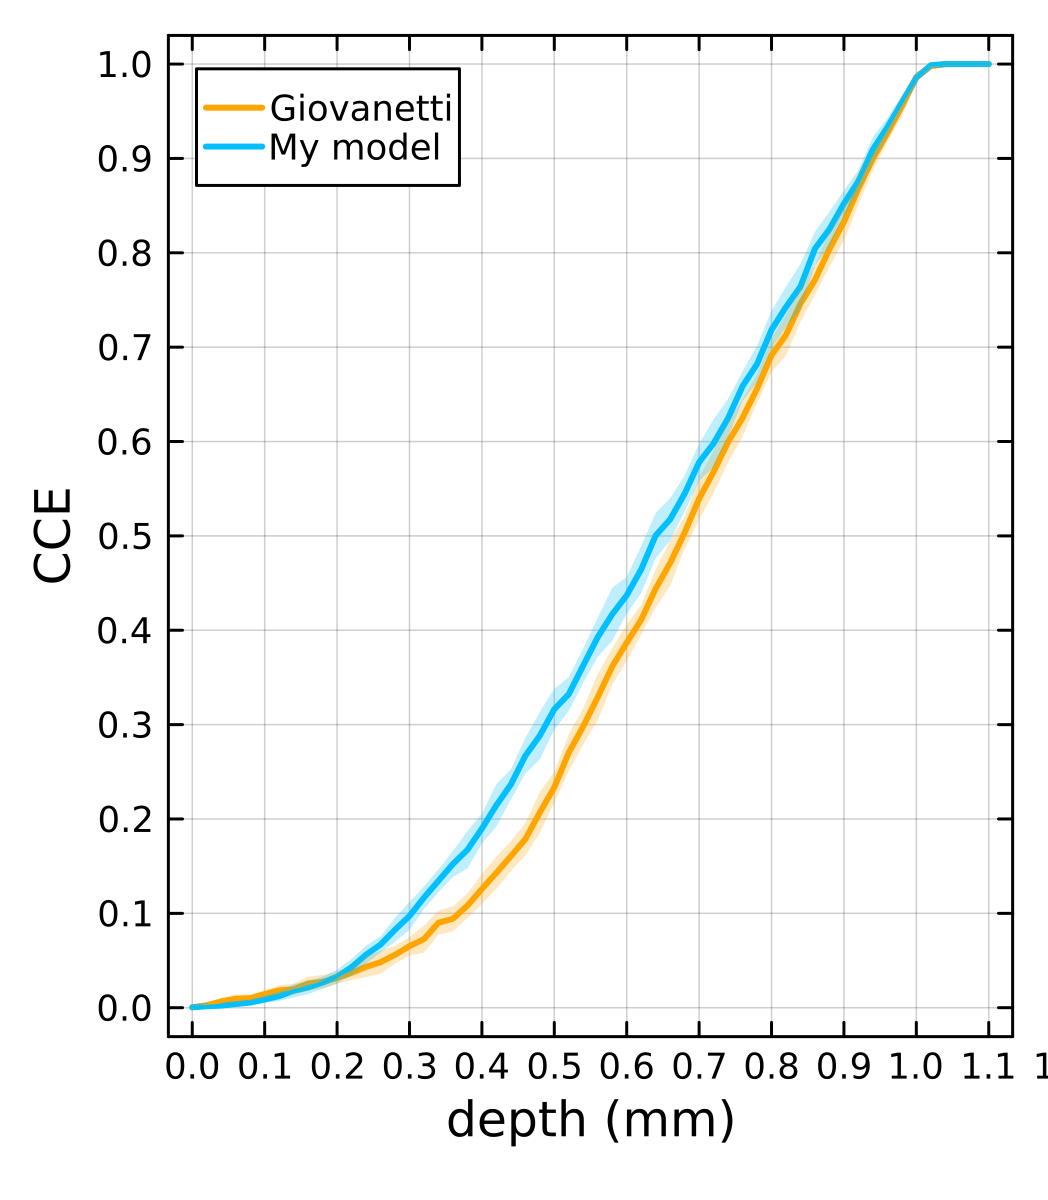

In [9]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1


plt = plot(xg.*10, cceg, lw=2, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label="Giovanetti",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), 
    frame=:box, size=(350, 400), dpi = 300
)
plot!(xmm.*10, ccemm, lw=2, color=:deepskyblue, label = "My model")

plot!(
    xg.*10, 
    cceg,
        ribbon=errg,
        fillalpha=0.25,
        color=:orange,
        label=false
)
plot!(
    xmm.*10, 
    ccemm,
        ribbon=errmm,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)



savefig(plt, "plot/CCE_comparison_giovanetti_mymodel.png")
display(plt)

# comparison Diffusion 

In [11]:
# questa è la curva CCE fatta con il codice di gioavnetti con D(x), 500 charges, 25 rep
xD, cceD, errD, params_loaded = load_CCE_results("my model/Diffusivity_CCE_3D.json");
# questa è la curva CCE fatta con il mio codice, dx = 20 um, 500 charges, 25 rep
xmm, ccemm, errmm, params_loaded = load_CCE_results("my model/My-uncomplete-model-3D.json");



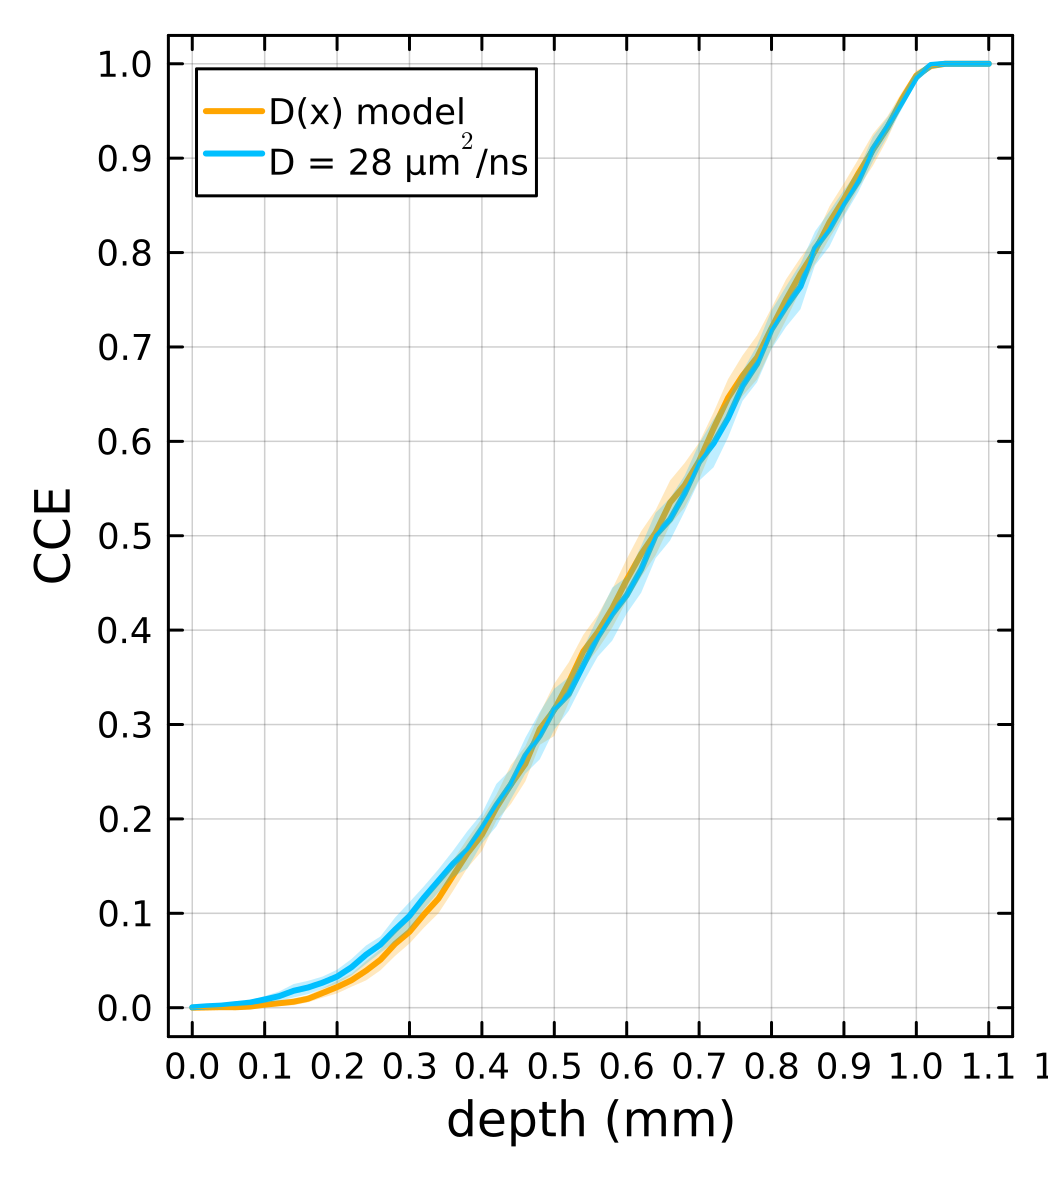

In [14]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1


plt = plot(xD.*10, cceD, lw=2, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label="D(x) model",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), 
    frame=:box, size=(350, 400), dpi = 300
)
plot!(xmm.*10, ccemm, lw=2, color=:deepskyblue, label = "D = 28 μm\$^2\$/ns")

plot!(
    xD.*10, 
    cceD,
        ribbon=errD,
        fillalpha=0.25,
        color=:orange,
        label=false
)
plot!(
    xmm.*10, 
    ccemm,
        ribbon=errmm,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)



savefig(plt, "plot/CCE_comparison_diffusivity_comparison.png")
display(plt)

# Confronto My classic code + RDR Radford

In [3]:
xmm, ccemm, errmm, params_loaded = load_CCE_results("my model/My-uncomplete-model-3D.json");
xrdr, ccerdr, errrdr, params_loaded = load_CCE_results("my model/RDR model/JSON/Nd(x)-Nsat.json");


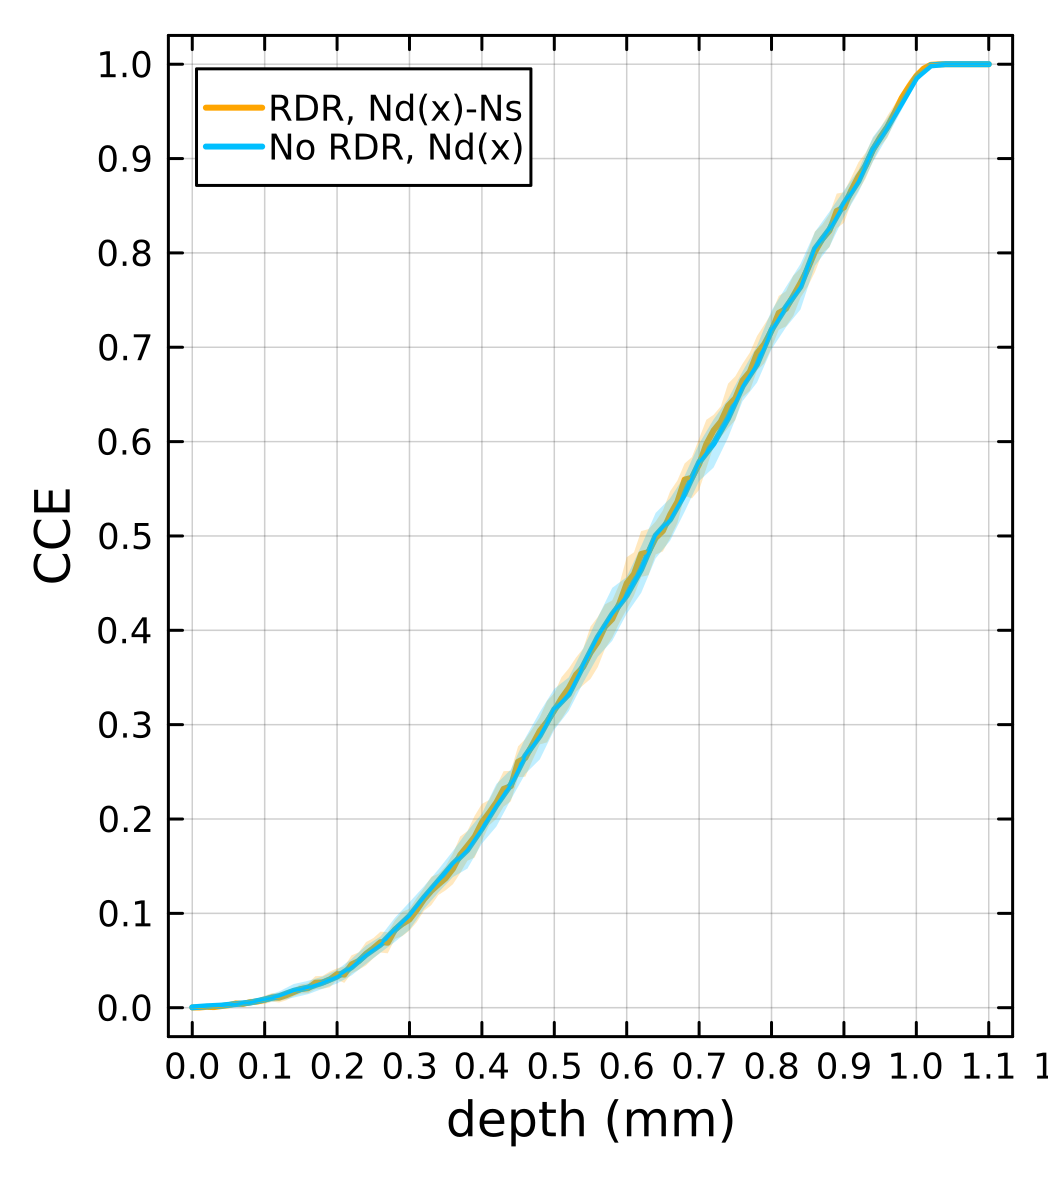

In [4]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1


plt = plot(xrdr.*10, ccerdr, lw=2, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label="RDR, Nd(x)-Ns",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), 
    frame=:box, size=(350, 400), dpi = 300
)
plot!(xmm.*10, ccemm, lw=2, color=:deepskyblue, label = "No RDR, Nd(x)")

plot!(
    xrdr.*10, 
    ccerdr,
        ribbon=errrdr,
        fillalpha=0.25,
        color=:orange,
        label=false
)
plot!(
    xmm.*10, 
    ccemm,
        ribbon=errmm,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)



savefig(plt, "plot/CCE_comparison_presenceRDR-Nd(x)-Ns.png")
display(plt)

# My RDR model and Li size play

In [6]:
xrdr, ccerdr, errrdr, params_loaded = load_CCE_results("my model/RDR model/JSON/Nd(x)-Nsat.json");

x_200_100_20, cce_200_100_20, errr_200_100_20, params_loaded = load_CCE_results("my model/RDR model/JSON/Nd(x)-Nsat_variable_radius.json");




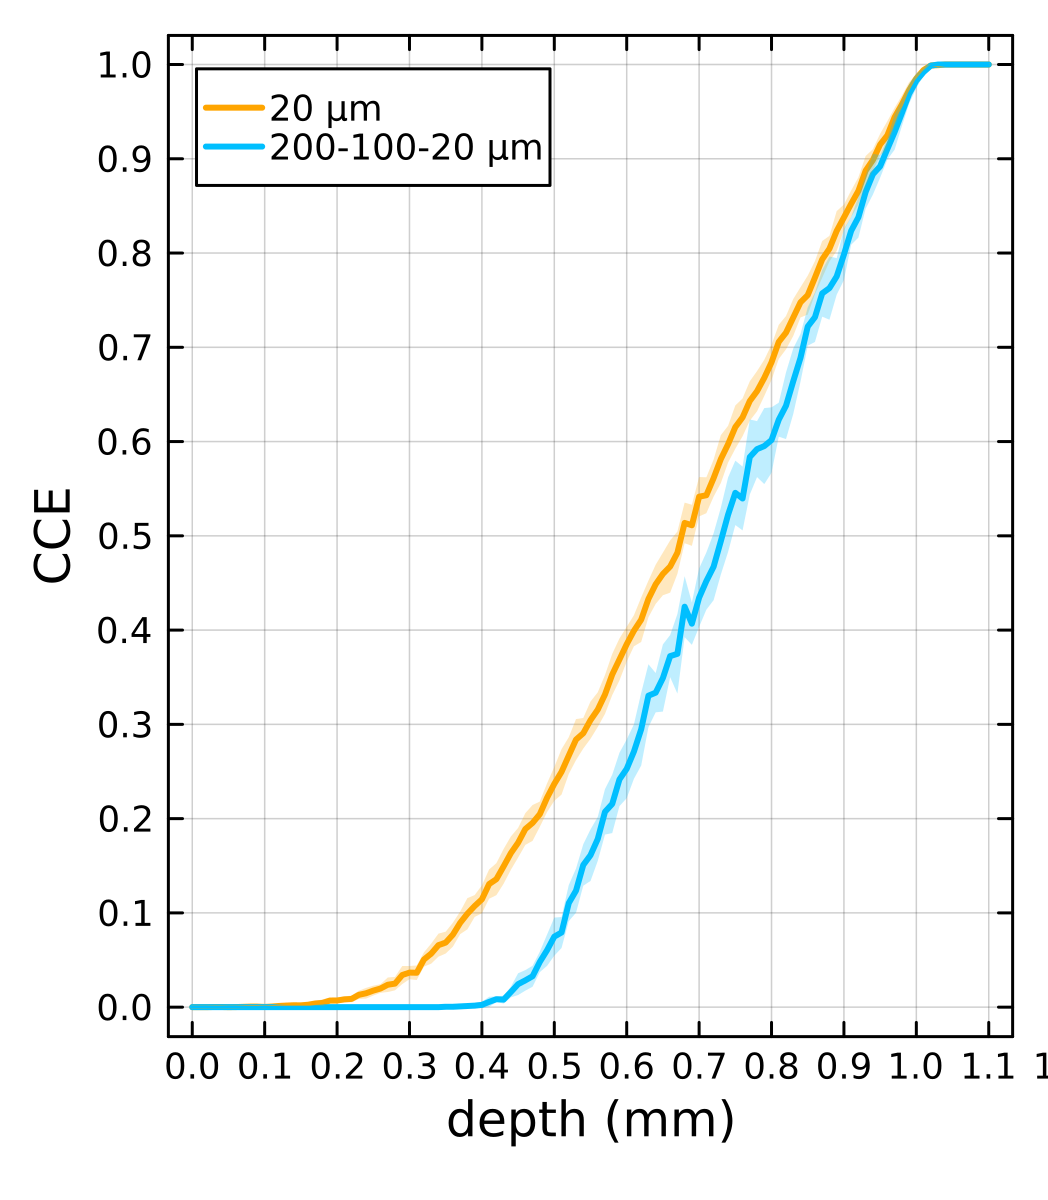

In [8]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1


plt = plot(xrdr.*10, ccerdr, lw=2, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label="20 μm",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), 
    frame=:box, size=(350, 400), dpi = 300
)
plot!(x_200_100_20.*10, cce_200_100_20, lw=2, color=:deepskyblue, label = "200-100-20 μm")

plot!(
    xrdr.*10, 
    ccerdr,
        ribbon=errrdr,
        fillalpha=0.25,
        color=:orange,
        label=false
)
plot!(
    x_200_100_20.*10, 
    cce_200_100_20,
        ribbon=errr_200_100_20,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)



savefig(plt, "plot/CCE_comparison_presenceRDR-Nd(x)-Ns.png")
display(plt)

# Diffusion code comparison 60 um

In [8]:
using JSON

file1 = "my model/RDR model/JSON/CCE_Diffusion_Rli=60.0_μm_bis.json"
file2 = "my model/RDR model/JSON/CCE_Diffusion_Rli=60.0_μm.json"

data_bis = JSON.parsefile(file1)
data = JSON.parsefile(file2);

x_pos = data["x_pos"];

In [9]:
sigma_keys = filter(k -> k != "x_pos", keys(data))
sigma_keys = sort(collect(filter(k -> k != "x_pos", keys(data))))

4-element Vector{String}:
 "sigma_13.17um"
 "sigma_22.81um"
 "sigma_29.44um"
 "sigma_41.64um"

In [10]:
sigma_arr = ["13 μm", "23 μm", "29 μm", "41 μm",]

4-element Vector{String}:
 "13 μm"
 "23 μm"
 "29 μm"
 "41 μm"

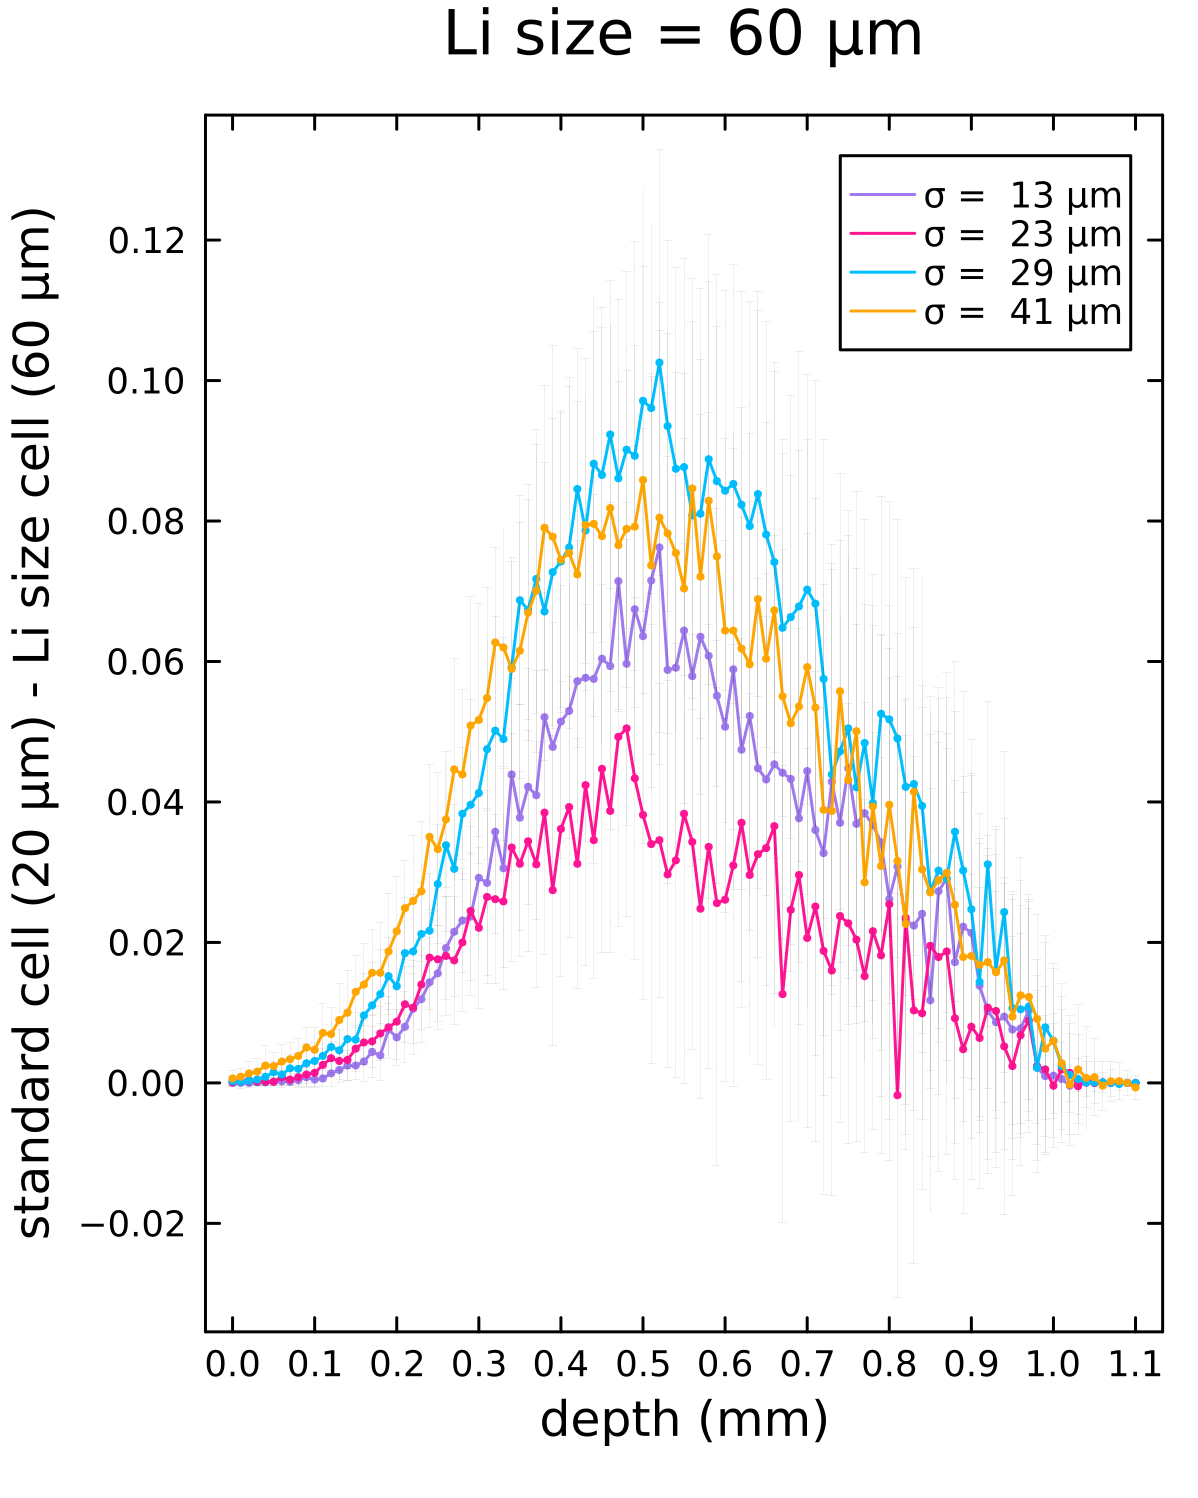

"/home/ritaferi/Phd/ChargeTrappingModel_dev/my model/RDR model/plot/delta_CCE_60μm.png"

In [11]:
p = plot(
    xlabel="depth (mm)",
    ylabel="standard cell (20 μm) - Li size cell (60 μm)",
    frame=:box,
    dpi=300,
    grid = false,
    
    #ylim = [-0.01, 0.12],
    size=(400, 500),
    title="Li size = 60 μm",
    xticks=0:0.1:1.1,
    #yticks=-0.01:0.01:0.12
)


colors = [:mediumpurple2, :deeppink, :deepskyblue, :orange, :lime]

# =====================
# LOOP OVER SIGMA
# =====================
for (k, key) in enumerate(sigma_keys)

    
    CCE1 = data[key]["CCE_mean"] # data = raggio 60 μm - cell size 20 μm
    CCE2 = data_bis[key]["CCE_mean"] # data = raggio 60 μm == cell size 

    STD1 = data[key]["CCE_std"]
    STD2 = data_bis[key]["CCE_std"]

    diff = CCE1 .- CCE2  # 
    err_diff = sqrt.(STD1.^2 .+ STD2.^2)

    # LINE
    plot!(
        p,
        x_pos .* 10,
        diff,
        lw=1,
        color=colors[k],
        label="σ =  $(sigma_arr[k])"
    )

    # POINTS + ERROR BARS
    scatter!(
        p,
        x_pos .* 10,
        diff,
        markersize=1.5,
        markerstrokewidth=0,
        color=colors[k],
        yerror=err_diff,
        label=""
    )
end

display(p)

savefig(p, "my model/RDR model/plot/delta_CCE_60μm.png")

# Comparison 120 mum

In [19]:
using JSON

file1 = "my model/RDR model/JSON/CCE_Diffusion_Rli=120.0_μm_bis.json"
file2 = "my model/RDR model/JSON/CCE_Diffusion_Rli=120.0_μm.json"

data_bis = JSON.parsefile(file1)
data = JSON.parsefile(file2);

x_pos = data["x_pos"];

In [20]:
sigma_keys = filter(k -> k != "x_pos", keys(data))
sigma_keys = sort(collect(filter(k -> k != "x_pos", keys(data))))

4-element Vector{String}:
 "sigma_13.17um"
 "sigma_22.81um"
 "sigma_29.44um"
 "sigma_41.64um"

In [21]:
sigma_arr = ["13 μm", "23 μm", "29 μm", "41 μm",]

4-element Vector{String}:
 "13 μm"
 "23 μm"
 "29 μm"
 "41 μm"

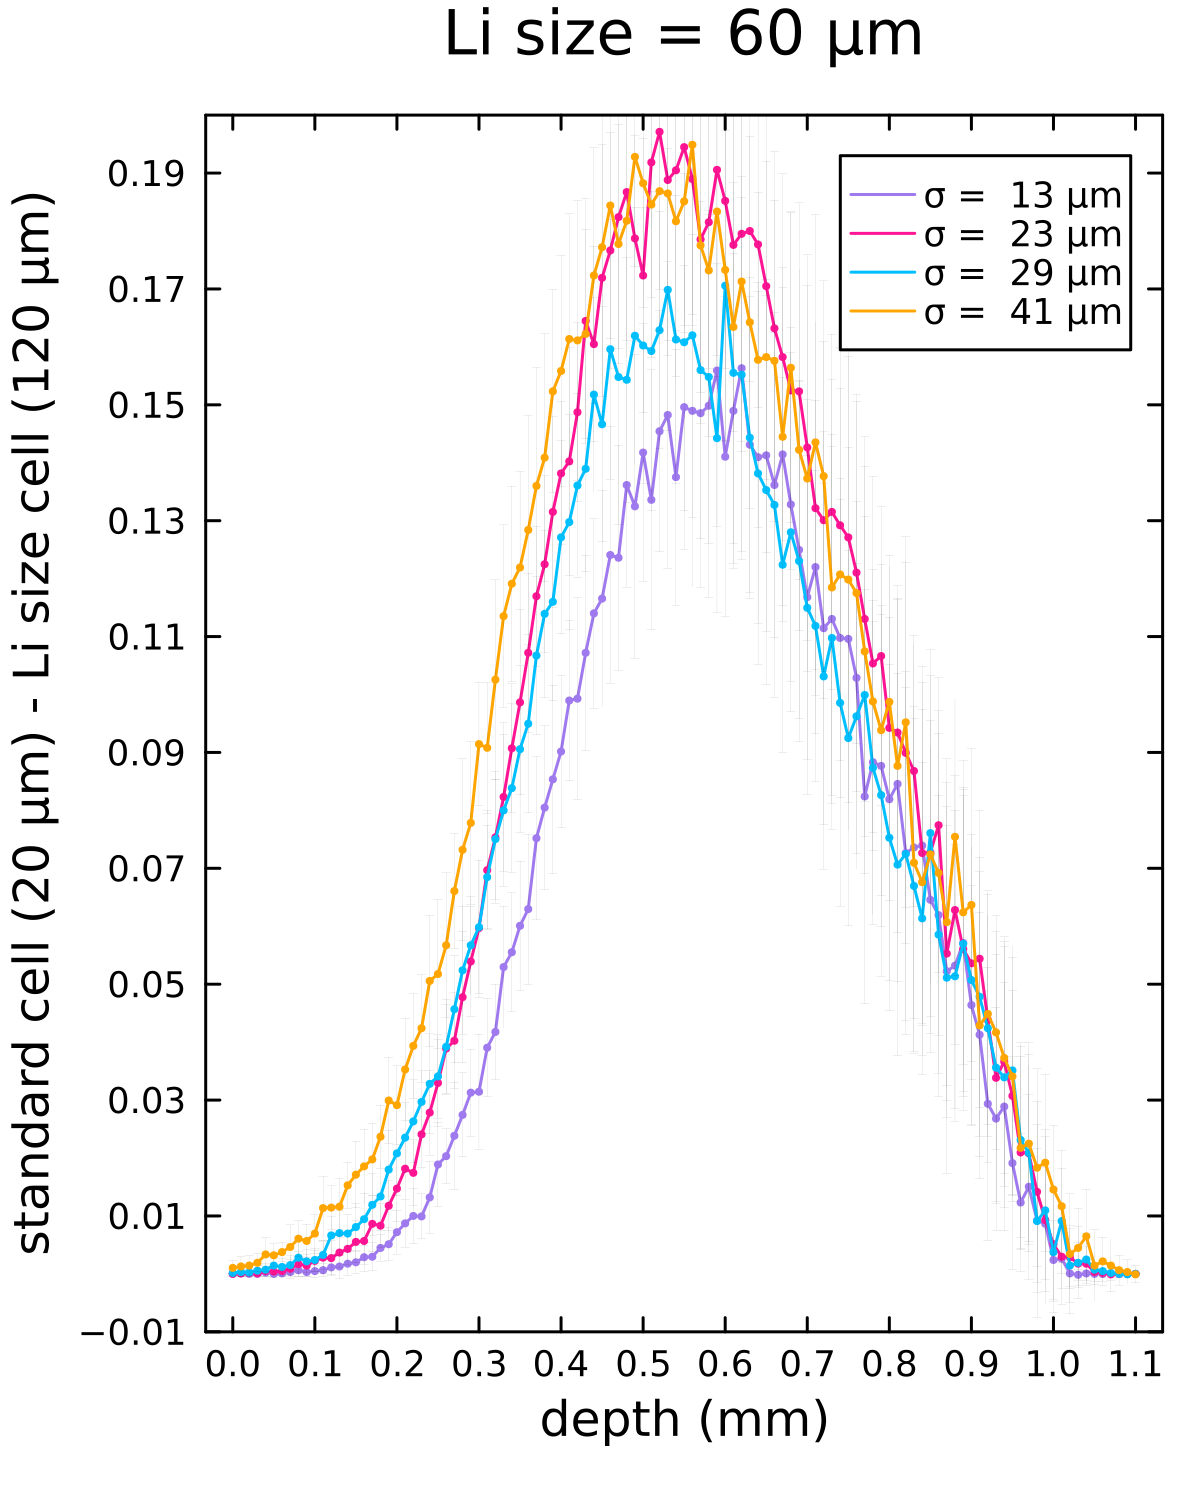

"/home/ritaferi/Phd/ChargeTrappingModel_dev/my model/RDR model/plot/delta_CCE_120μm.png"

In [25]:
p = plot(
    xlabel="depth (mm)",
    ylabel="standard cell (20 μm) - Li size cell (120 μm)",
    frame=:box,
    dpi=300,
    grid = false,
    
    ylim = [-0.01, 0.2],
    size=(400, 500),
    title="Li size = 60 μm",
    xticks=0:0.1:1.1,
    yticks=-0.01:0.02:0.2
)


colors = [:mediumpurple2, :deeppink, :deepskyblue, :orange, :lime]

# =====================
# LOOP OVER SIGMA
# =====================
for (k, key) in enumerate(sigma_keys)

    
    CCE1 = data[key]["CCE_mean"] # data = raggio 60 μm - cell size 20 μm
    CCE2 = data_bis[key]["CCE_mean"] # data = raggio 60 μm == cell size 

    STD1 = data[key]["CCE_std"]
    STD2 = data_bis[key]["CCE_std"]

    diff = CCE1 .- CCE2  # 
    err_diff = sqrt.(STD1.^2 .+ STD2.^2)

    # LINE
    plot!(
        p,
        x_pos .* 10,
        diff,
        lw=1,
        color=colors[k],
        label="σ =  $(sigma_arr[k])"
    )

    # POINTS + ERROR BARS
    scatter!(
        p,
        x_pos .* 10,
        diff,
        markersize=1.5,
        markerstrokewidth=0,
        color=colors[k],
        yerror=err_diff,
        label=""
    )
end

display(p)

savefig(p, "my model/RDR model/plot/delta_CCE_120μm.png")

# confronto 20 um

In [33]:
using JSON

file1 = "my model/RDR model/JSON/CCE_Diffusion_Rli=20.0_μm_bis.json"
file2 = "my model/RDR model/JSON/CCE_Diffusion_Rli=20.0_μm.json"

data_bis = JSON.parsefile(file1)
data = JSON.parsefile(file2);

x_pos = data["x_pos"];

In [34]:
sigma_keys = filter(k -> k != "x_pos", keys(data))
sigma_keys = sort(collect(filter(k -> k != "x_pos", keys(data))))

4-element Vector{String}:
 "sigma_13.17um"
 "sigma_22.81um"
 "sigma_29.44um"
 "sigma_41.64um"

In [35]:
sigma_arr = ["13 μm", "23 μm", "29 μm", "41 μm",]

4-element Vector{String}:
 "13 μm"
 "23 μm"
 "29 μm"
 "41 μm"

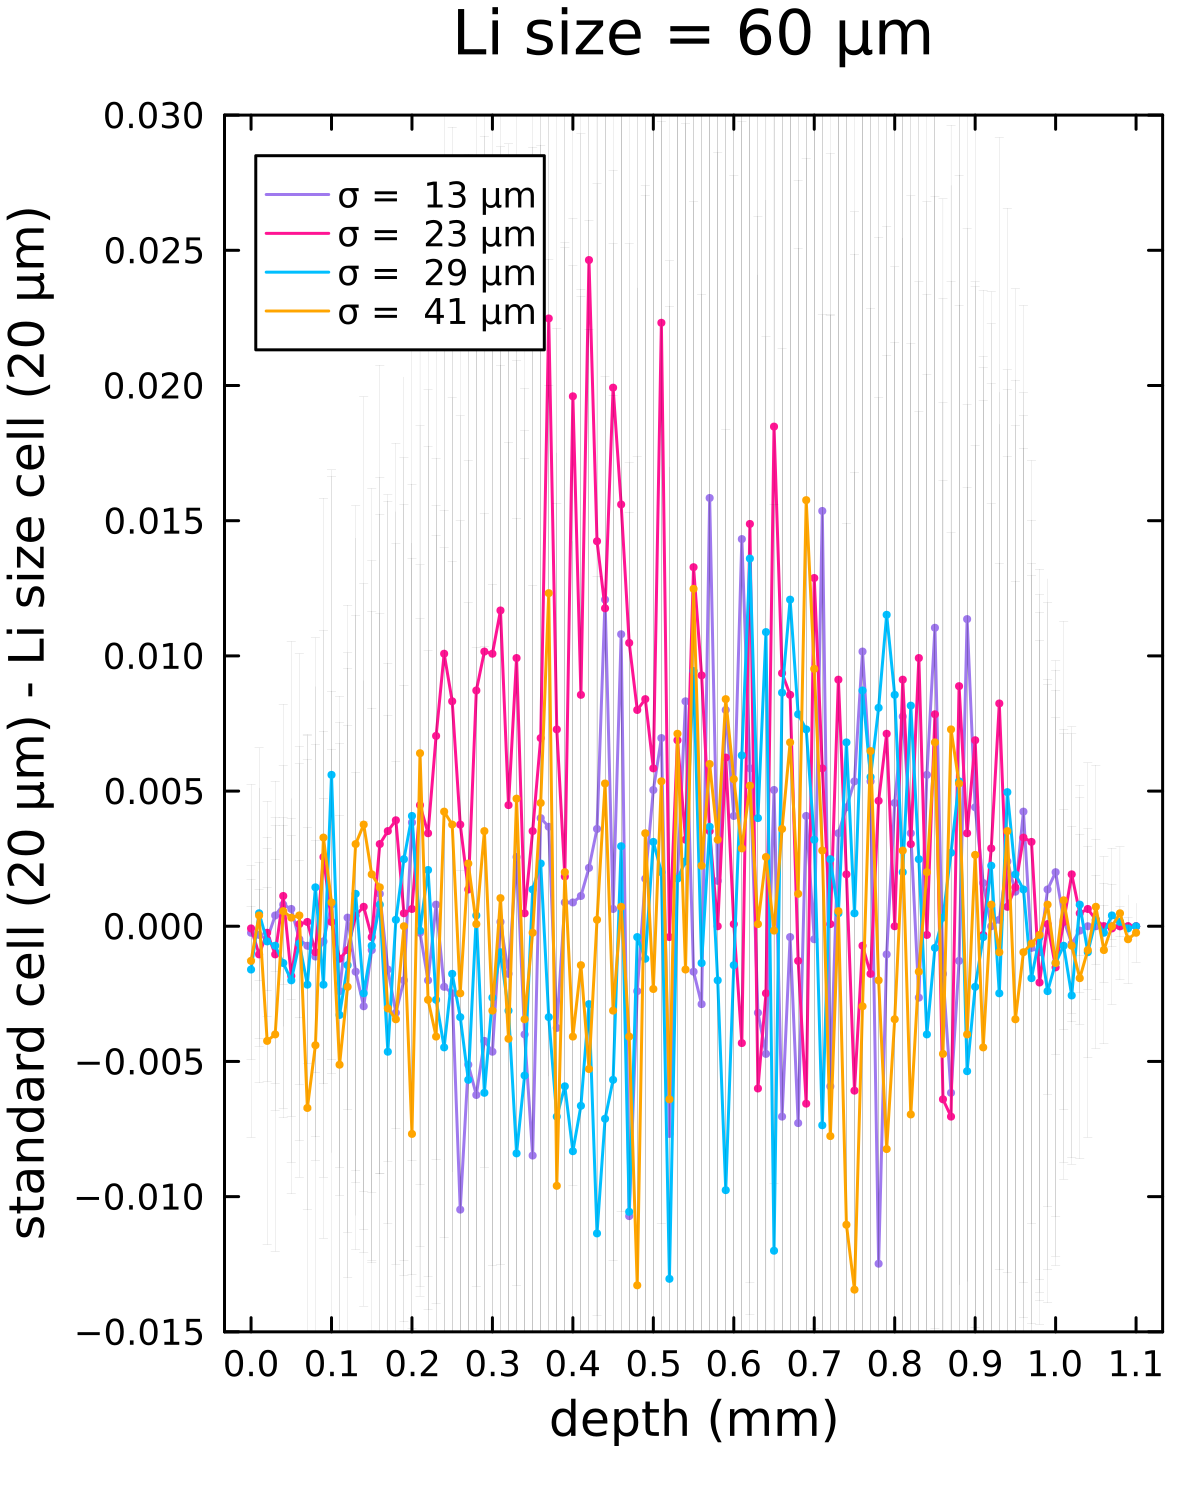

"/home/ritaferi/Phd/ChargeTrappingModel_dev/my model/RDR model/plot/delta_CCE_20μm.png"

In [41]:

p = plot(
    xlabel="depth (mm)",
    ylabel="standard cell (20 μm) - Li size cell (20 μm)",
    frame=:box,
    dpi=300,
    grid = false,
    
    ylim = [-0.015, 0.03],
    size=(400, 500),
    title="Li size = 60 μm",
    xticks=0:0.1:1.1,
    yticks=-0.015:0.005:0.03
)


colors = [:mediumpurple2, :deeppink, :deepskyblue, :orange, :lime]

# =====================
# LOOP OVER SIGMA
# =====================
for (k, key) in enumerate(sigma_keys)

    
    CCE1 = data[key]["CCE_mean"] # data = raggio 60 μm - cell size 20 μm
    CCE2 = data_bis[key]["CCE_mean"] # data = raggio 60 μm == cell size 

    STD1 = data[key]["CCE_std"]
    STD2 = data_bis[key]["CCE_std"]

    diff = CCE1 .- CCE2  # 
    err_diff = sqrt.(STD1.^2 .+ STD2.^2)

    # LINE
    plot!(
        p,
        x_pos .* 10,
        diff,
        lw=1,
        color=colors[k],
        label="σ =  $(sigma_arr[k])"
    )

    # POINTS + ERROR BARS
    scatter!(
        p,
        x_pos .* 10,
        diff,
        markersize=1.5,
        markerstrokewidth=0,
        color=colors[k],
        yerror=err_diff,
        label=""
    )
end

display(p)

savefig(p, "my model/RDR model/plot/delta_CCE_20μm.png")

# Coparison : Li size = 20 um, but cell size = 20 um vs 50 um

In [14]:
using JSON

x_20, cce_20, err_20, params_loaded = load_CCE_results("my model/json-CCE-file/My-model+RDR.json");

x_120, cce_120, err_120, params_loaded = load_CCE_results("my model/RDR model/JSON/Nd(x)-Nsat-cell=120um.json")


x_240, cce_240, err_240, params_loaded = load_CCE_results("my model/RDR model/JSON/Nd(x)-Nsat-cell=240um.json")

([0.0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009  …  0.101, 0.102, 0.103, 0.104, 0.105, 0.106, 0.107, 0.108, 0.109, 0.11], [0.0002, 0.00013333333333333334, 0.0008666666666666667, 0.0013333333333333333, 0.0024666666666666656, 0.002666666666666665, 0.003866666666666665, 0.004733333333333331, 0.005533333333333332, 0.005599999999999998  …  0.9956000000000003, 0.998866666666667, 0.9996, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [0.0007996597916069839, 0.0006598288790738577, 0.0018820069376542393, 0.002332847374079218, 0.0034869370740995827, 0.002332847374079217, 0.0035225222874108444, 0.004316818346296336, 0.0033408079460553104, 0.004638398347385113  …  0.0038356248696385354, 0.0017313960916854978, 0.0010942024088643751, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Dict{Any, Any}())

In [82]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1



plt = plot(x_20.*10, cce_20, lw=2, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label="cell size = 20 μm",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), 
    frame=:box, size=(350, 400), dpi = 300
)
plot!(x_120.*10, cce_120, lw=2, color=:deepskyblue, label = "cell size = 120 μm")
plot!(x_240.*10, cce_240, lw=2, color=:green, label = "cell size = 240 μm")


plot!(
    x_20.*10, 
    cce_20,
        ribbon=err_20,
        fillalpha=0.25,
        color=:orange,
        label=false
)


plot!(
    x_120.*10, 
    cce_120,
        ribbon=err_120,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)

plot!(
    x_240.*10, 
    cce_240,
        ribbon=err_240,
        fillalpha=0.25,
        color=:green,
        label=false
)


savefig(plt, "plot/CCE_comparison_grid_sizes.png")
display(plt)

UndefVarError: UndefVarError: `x_240` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# confronto CCE sono 20 um  VS 120 um - 20 um

x_20new, cce_20new, err_20new, params_loaded = load_CCE_results("my model/RDR model/JSON-multi-size/CCE_20.0um_20um.json");
x_30new, cce_30new, err_30new, params_loaded = load_CCE_results("my model/RDR model/JSON-multi-size/CCE_30.0um_20um.json");
x_40new, cce_40new, err_40new, params_loaded = load_CCE_results("my model/RDR model/JSON-multi-size/CCE_40.0um_20um.json");
x_60new, cce_60new, err_60new, params_loaded = load_CCE_results("my model/RDR model/JSON-multi-size/CCE_60.0um_20um.json");
x_80new, cce_80new, err_80new, params_loaded = load_CCE_results("my model/RDR model/JSON-multi-size/CCE_80.0um_20um.json");
x_120new, cce_120new, err_120new, params_loaded = load_CCE_results("my model/RDR model/JSON-multi-size/CCE_120.0um_20um.json");

In [24]:
x_20, cce_20, err_20, params_loaded = load_CCE_results("JSON-packing/CCE_20.0um_20um.json");
x_30, cce_30, err_30, params_loaded = load_CCE_results("JSON-packing/CCE_30.0um_20um_CORRETTO.json");
x_40, cce_40, err_40, params_loaded = load_CCE_results("JSON-packing/CCE_40.0um_20um.json");
x_60, cce_60, err_60, params_loaded = load_CCE_results("JSON-packing/CCE_60.0um_20um.json");
x_80, cce_80, err_80, params_loaded = load_CCE_results("JSON-packing/CCE_80.0um_20um.json");
x_120, cce_120, err_120, params_loaded = load_CCE_results("JSON-packing/CCE_120.0um_20um.json");

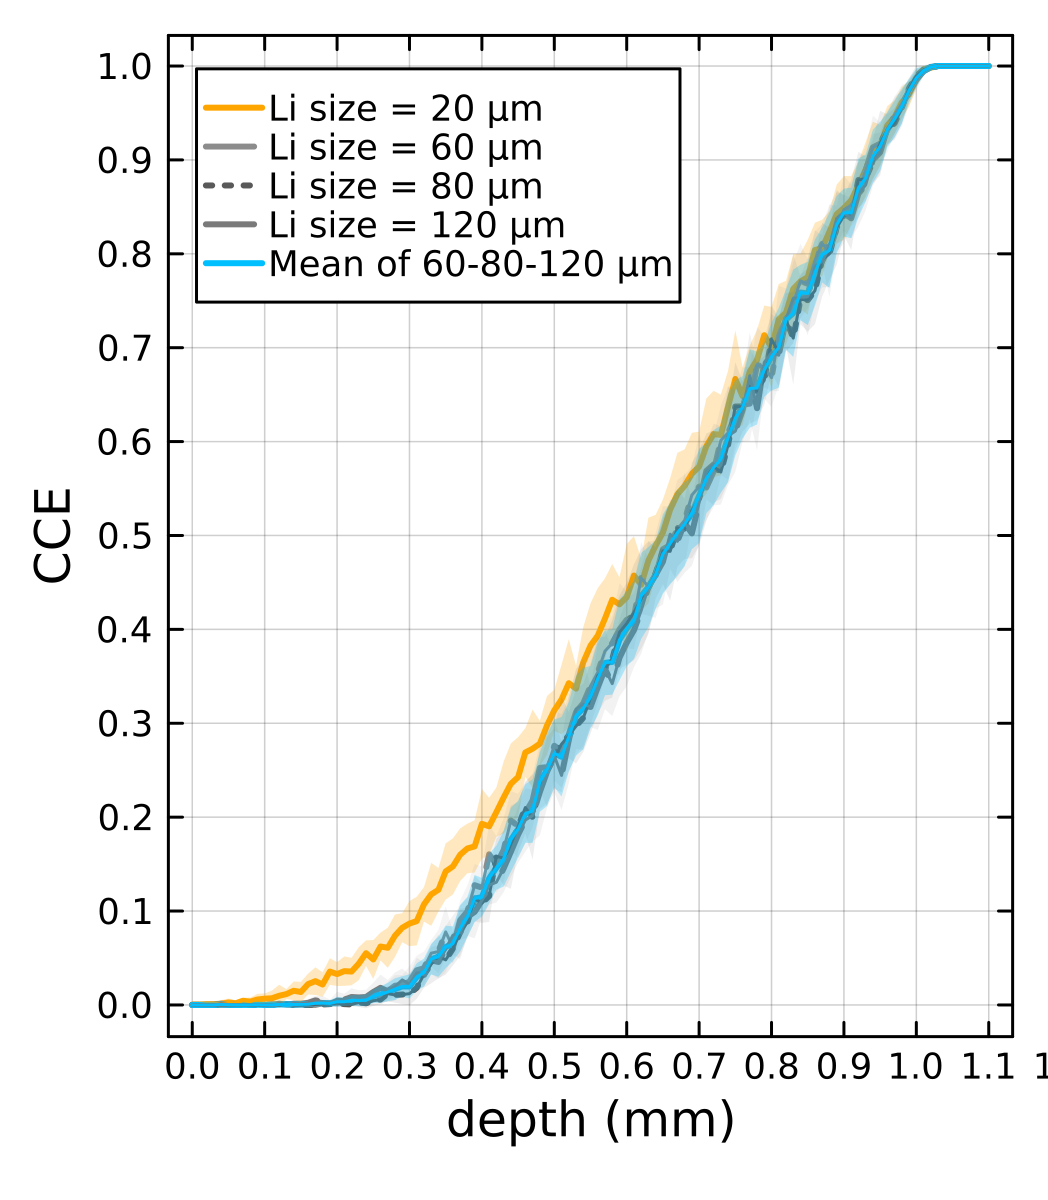

In [28]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1



plt = plot(x_20.*10, cce_20, lw=2, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label="Li size = 20 μm",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), 
    frame=:box, size=(350, 400), dpi = 300
)
#plot!(x_30.*10, cce_30, lw=2, label="Li size = 30 μm ")
#plot!(x_40.*10, cce_40, lw=2, label="Li size = 40 μm ")
plot!(x_60.*10, cce_60, lw=2, 
color = :gray55,
 ls = :dashdot,
  label="Li size = 60 μm ")

plot!(x_80.*10, cce_80, lw=2, 
color = :gray35, 
ls = :dot,
 label="Li size = 80 μm ")

plot!(x_120.*10, cce_120, lw=2,
 color = :gray48, 
 ls = :dash, 
 label="Li size = 120 μm ")

plot!(x_120.*10, mean([cce_120, cce_60, cce_80]), lw=2, color=:deepskyblue, label="Mean of 60-80-120 μm")


plot!(
    x_20.*10, 
    cce_20,
        ribbon=err_20,
        color = :orange,
        fillalpha=0.25,
        label=false)


  #=
plot!(
    x_30.*10, 
    cce_30,
        ribbon=err_30,
        fillalpha=0.25,
        label=false)



plot!(
    x_40.*10, 
    cce_40,
        ribbon=err_40,
        fillalpha=0.25,
        label=false)

  =#     
plot!(
    x_60.*10, 
    cce_60,
    color = :gray55,
        ribbon=err_60,
        fillalpha=0.1,
        label=false)
      
plot!(
    x_80.*10, 
    cce_80,
    color = :gray35,
        ribbon=err_80,
        fillalpha=0.1, 
        label=false)

        
plot!(
    x_120.*10, 
    cce_120,
    color = :gray48,
        ribbon=err_120,
        fillalpha=0.1,
        label=false)


plot!(
    x_120.*10, 
    mean([cce_120, cce_60, cce_80]),
    color=:deepskyblue,
        ribbon=mean([err_120, err_60, err_80]),
        fillalpha=0.28,
        label=false) 
#savefig(plt, "plot/CCE_20umONLY_120um+20um+120um+20um.png")
display(plt)

# confronto solo 20 um - 120 um + 20 um - 6 fette di diverso raggio

In [ ]:
x_20, cce_20, err_20, params_loaded = load_CCE_results("JSON-packing/CCE_20.0um_20um.json");
x_120, cce_120, err_120, params_loaded = load_CCE_results("JSON-packing/CCE_120.0um_20um.json");


x_fixes, cce_fixes, err_fixes, params_loaded = load_CCE_results("");

([0.0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009  …  0.101, 0.102, 0.103, 0.104, 0.105, 0.106, 0.107, 0.108, 0.109, 0.11], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.99475, 0.99925, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.004435206041615089, 0.0018317377426626178, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Dict{Any, Any}())

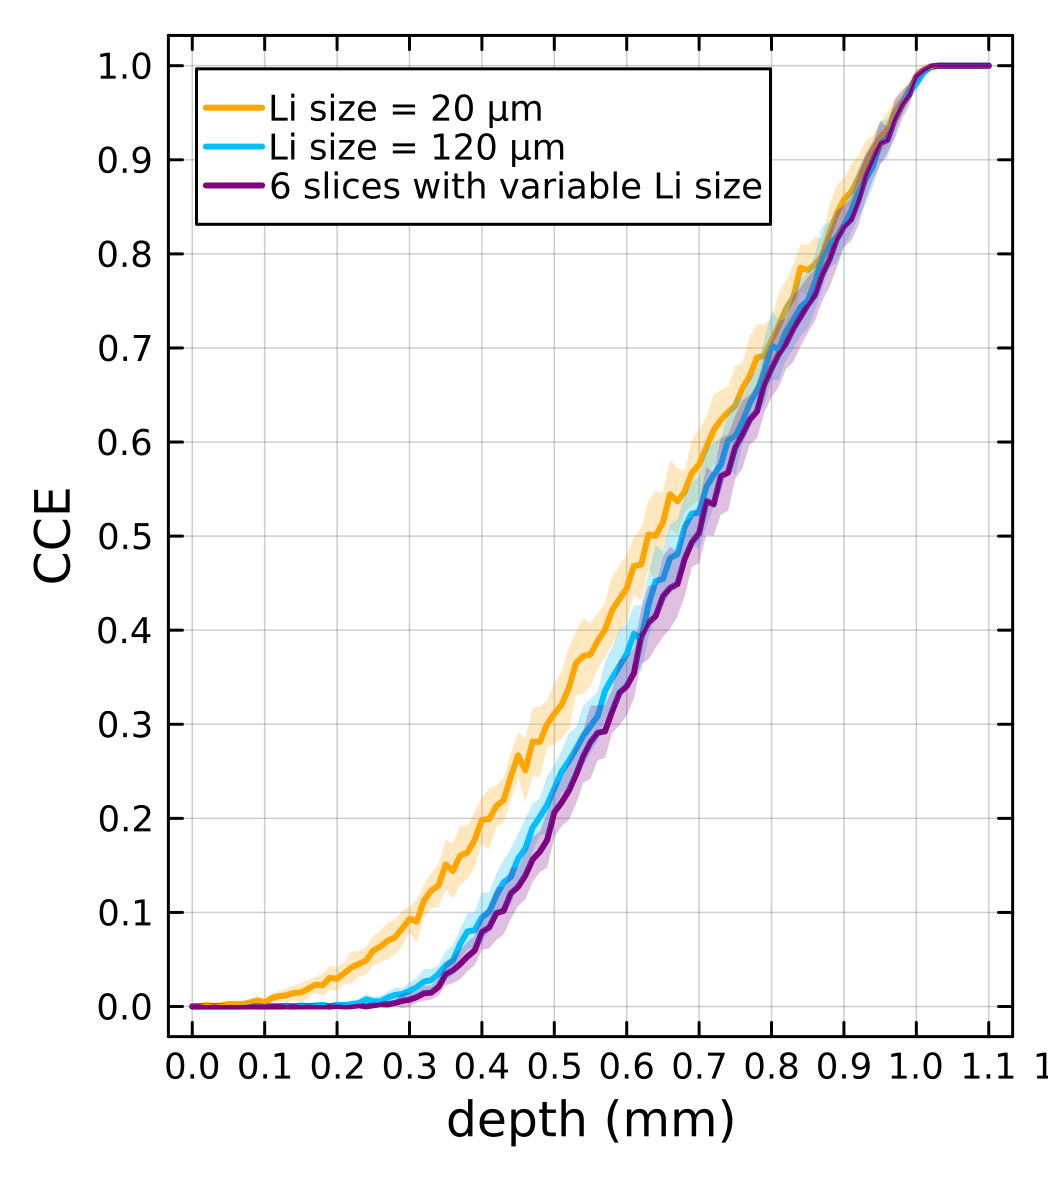

In [87]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1



plt = plot(x_20new.*10, cce_20new, lw=2, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label="Li size = 20 μm",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), 
    frame=:box, size=(350, 400), dpi = 300
)


plot!(x_120new.*10, cce_120new, lw=2, color = :deepskyblue,  label="Li size = 120 μm ")
plot!(x_slice.*10, cce_slice, lw=2, color=:purple, label="6 slices with variable Li size")
plot!(
    x_20new.*10, 
    cce_20new,
        ribbon=err_20new,
        color = :orange,
        fillalpha=0.25,
        label=false)

plot!(
    x_120new.*10, 
    cce_120new,
        ribbon=err_120new,
        color = :deepskyblue,
        fillalpha=0.25, 
        label=false)
plot!(
    x_slice.*10, 
    cce_slice,
        ribbon=err_slice,
        color=:purple,
        fillalpha=0.25,
        label=false)

# confronto 120 um e molte carice da 120 


In [21]:
x_120, cce_120, err_120, params_loaded = load_CCE_results("my model/RDR model/JSON/CCE_120um_20um.json")
x_molte20, cce_molte20, err_molte20 = params = load_CCE_results("CCE_20um_comaprison_with120um.json")


([0.0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009  …  0.101, 0.102, 0.103, 0.104, 0.105, 0.106, 0.107, 0.108, 0.109, 0.11], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.99552, 0.9990399999999999, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0038850139424889277, 0.0017435595774162708, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Dict{Any, Any}())

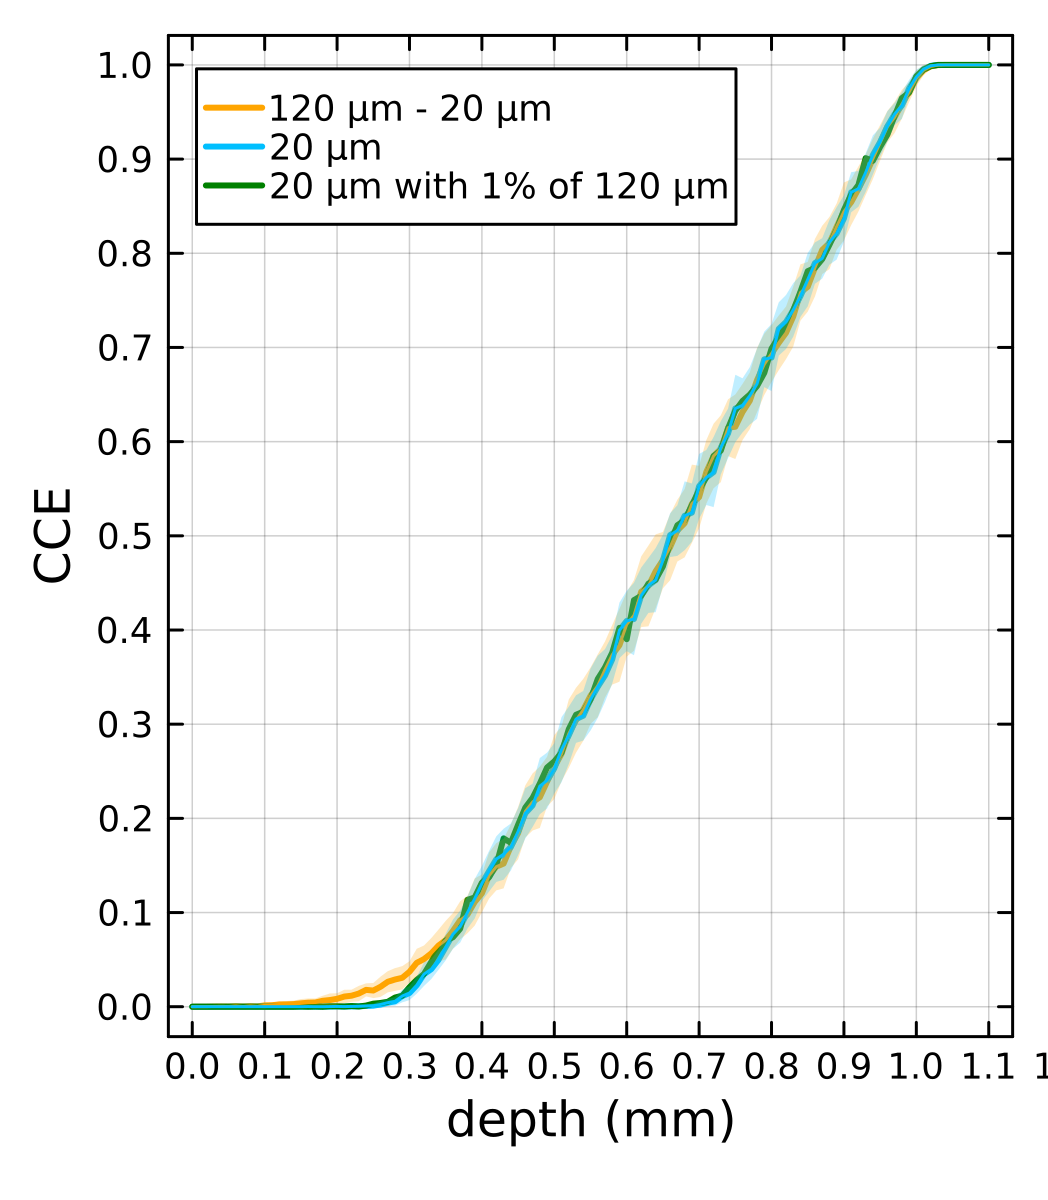

In [22]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1



plt = plot(
    xlabel="depth (mm)", ylabel="CCE", label="Li size = 20 μm",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), 
    frame=:box, size=(350, 400), dpi = 300
)

plot!(x_120.*10, cce_120, lw=2, color=:orange, label="120 μm - 20 μm")
plot!(x_molte20.*10, cce_molte20, lw=2, color=:deepskyblue, label="20 μm")
plot!(x_molte20new.*10, cce_molte20new, lw=2, color=:green, label="20 μm with 1% of 120 μm")


plot!(
    x_120.*10, 
    cce_120,
        ribbon=err_120,
        color = :orange,
        fillalpha=0.25,
        label=false)
plot!(
    x_molte20.*10, 
    cce_molte20,
        ribbon=err_molte20,
        color = :deepskyblue,
        fillalpha=0.25,
        label=false)


In [16]:
(0.001*0.2*0.2) * 0.001 / (4/3 * π * 0.002^3 * 2 * 0.002) 

298.4155182973038